# **ANALISIS MENGGUNAKAN UJI CHI-SQUARE**

----------------------------

- Link Dataset 1: https://www.bps.go.id/id/statistics-table/2/Mzk4IzI=/persentase-rumah-tangga-yang-pernah-mengakses-internet-dalam-3-bulan-terakhir-menurut-provinsi-dan-klasifikasi-daerah.html

- Link Dataset 2: https://www.bps.go.id/id/statistics-table/2/MTkyIzI=/persentase-penduduk-miskin--p0--menurut-provinsi-dan-daerah.htmlh

## **1. Pengumpulan Data**

In [ ]:
# ================================================================================
# BAGIAN 1: PENGUMPULAN DATA
# ================================================================================

print("="*80)
print("BAGIAN 1: PENGUMPULAN DATA")
print("="*80)

# --------------------------------------------------------------------------------
# 1.1 Import Library
# --------------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Library berhasil di-import\n")

# --------------------------------------------------------------------------------
# 1.2 Upload File
# --------------------------------------------------------------------------------

from google.colab import files

print("Upload File 1: Dataset Akses Internet")
uploaded1 = files.upload()

print("\nUpload File 2: Dataset Kemiskinan")
uploaded2 = files.upload()

# --------------------------------------------------------------------------------
# 1.3 Load Dataset
# --------------------------------------------------------------------------------

print("\n" + "-"*80)
print("Memuat dataset...")
print("-"*80)

# Load dataset internet
file_internet = list(uploaded1.keys())[0]
df_internet_raw = pd.read_csv(file_internet, skiprows=3, encoding='utf-8')

print(f"\nDataset 1: {file_internet}")
print(f"Dimensi: {df_internet_raw.shape}")
print(f"\n5 baris pertama:")
print(df_internet_raw.head())

# Load dataset kemiskinan
file_poverty = list(uploaded2.keys())[0]
df_kemiskinan_raw = pd.read_csv(file_poverty, skiprows=4, encoding='utf-8')

print(f"\nDataset 2: {file_poverty}")
print(f"Dimensi: {df_kemiskinan_raw.shape}")
print(f"\n5 baris pertama:")
print(df_kemiskinan_raw.head())

# --------------------------------------------------------------------------------
# Ringkasan
# --------------------------------------------------------------------------------

print("\n" + "="*80)
print("RINGKASAN")
print("="*80)
print(f"Dataset 1 (Akses Internet): {df_internet_raw.shape[0]} baris, {df_internet_raw.shape[1]} kolom")
print(f"Dataset 2 (Kemiskinan): {df_kemiskinan_raw.shape[0]} baris, {df_kemiskinan_raw.shape[1]} kolom")
print("="*80)

BAGIAN 1: PENGUMPULAN DATA
Library berhasil di-import

Upload File 1: Dataset Akses Internet


Saving Persentase Rumah Tangga yang Pernah Mengakses Internet dalam 3 Bulan Terakhir Menurut Provinsi dan Klasifikasi Daerah, 2024.csv to Persentase Rumah Tangga yang Pernah Mengakses Internet dalam 3 Bulan Terakhir Menurut Provinsi dan Klasifikasi Daerah, 2024 (1).csv

Upload File 2: Dataset Kemiskinan


Saving Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah, 2024.csv to Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah, 2024 (1).csv

--------------------------------------------------------------------------------
Memuat dataset...
--------------------------------------------------------------------------------

Dataset 1: Persentase Rumah Tangga yang Pernah Mengakses Internet dalam 3 Bulan Terakhir Menurut Provinsi dan Klasifikasi Daerah, 2024 (1).csv
Dimensi: (39, 4)

5 baris pertama:
       Unnamed: 0   2024 2024.1  2024.2
0            ACEH  92.60  86.97   88.95
1  SUMATERA UTARA  94.77  89.05   92.30
2  SUMATERA BARAT  94.85  88.82   91.89
3            RIAU  97.26  92.12   94.16
4           JAMBI  93.01  89.41   90.59

Dataset 2: Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah, 2024 (1).csv
Dimensi: (39, 10)

5 baris pertama:
       Unnamed: 0  Semester 1 (Maret)  Semester 2 (September) Tahunan  \
0            ACEH                9.60              

## **2. Pembersihan & Transformasi Data**

In [ ]:
# ================================================================================
# BAGIAN 2: Pembersihan & Transformasi Data
# ================================================================================

print("="*80)
print("BAGIAN 2: Pembersihan & Transformasi Data")
print("="*80)

# --------------------------------------------------------------------------------
# 2.1 Cleaning Dataset Akses Internet
# --------------------------------------------------------------------------------

print("\n2.1 Cleaning Dataset Akses Internet")
print("-"*80)

# Rename kolom
df_internet = df_internet_raw.copy()
df_internet.columns = ['Provinsi', 'Internet_Perkotaan', 'Internet_Perdesaan', 'Internet_Total']

print(f"Kolom diubah: {df_internet.columns.tolist()}")

# Hapus baris Indonesia (agregat nasional)
df_internet = df_internet[df_internet['Provinsi'] != 'INDONESIA'].copy()
print(f"Baris 'INDONESIA' dihapus")

# Standarisasi nama provinsi
df_internet['Provinsi'] = df_internet['Provinsi'].str.strip().str.upper()

# Konversi ke numerik
for col in ['Internet_Perkotaan', 'Internet_Perdesaan', 'Internet_Total']:
    df_internet[col] = pd.to_numeric(df_internet[col], errors='coerce')

# Cek missing values
print(f"\nMissing values:")
print(df_internet.isnull().sum())
print(f"\nDimensi akhir: {df_internet.shape}")
print(f"Jumlah provinsi: {len(df_internet)}")

print("\nPreview data bersih:")
print(df_internet.head(10))

# --------------------------------------------------------------------------------
# 2.2 Cleaning Dataset Kemiskinan
# --------------------------------------------------------------------------------

print("\n\n2.2 Cleaning Dataset Kemiskinan")
print("-"*80)

df_kemiskinan = df_kemiskinan_raw.copy()

# Rename kolom
df_kemiskinan.columns = ['Provinsi',
                         'Kemiskinan_Perkotaan_Mar', 'Kemiskinan_Perkotaan_Sep', 'Tahunan_Perkotaan',
                         'Kemiskinan_Perdesaan_Mar', 'Kemiskinan_Perdesaan_Sep', 'Tahunan_Perdesaan',
                         'Kemiskinan_Total_Mar', 'Kemiskinan_Total_Sep', 'Tahunan_Total']

# Pilih kolom relevan (Maret 2024 untuk konsistensi temporal)
df_kemiskinan = df_kemiskinan[['Provinsi', 'Kemiskinan_Total_Mar']].copy()
df_kemiskinan.columns = ['Provinsi', 'Kemiskinan_Persen']

print(f"Kolom dipilih: {df_kemiskinan.columns.tolist()}")
print(f"Periode: Maret 2024 (Semester 1)")

# Hapus baris Indonesia
df_kemiskinan = df_kemiskinan[df_kemiskinan['Provinsi'] != 'INDONESIA'].copy()
print(f"Baris 'INDONESIA' dihapus")

# Standarisasi nama provinsi
df_kemiskinan['Provinsi'] = df_kemiskinan['Provinsi'].str.strip().str.upper()

# Konversi ke numerik
df_kemiskinan['Kemiskinan_Persen'] = pd.to_numeric(df_kemiskinan['Kemiskinan_Persen'], errors='coerce')

# Hapus missing values
df_kemiskinan = df_kemiskinan.dropna()

# Cek missing values
print(f"\nMissing values:")
print(df_kemiskinan.isnull().sum())
print(f"\nDimensi akhir: {df_kemiskinan.shape}")
print(f"Jumlah provinsi: {len(df_kemiskinan)}")

print("\nPreview data bersih:")
print(df_kemiskinan.head(10))

BAGIAN 2: Pembersihan & Transformasi Data

2.1 Cleaning Dataset Akses Internet
--------------------------------------------------------------------------------
Kolom diubah: ['Provinsi', 'Internet_Perkotaan', 'Internet_Perdesaan', 'Internet_Total']
Baris 'INDONESIA' dihapus

Missing values:
Provinsi              0
Internet_Perkotaan    0
Internet_Perdesaan    1
Internet_Total        0
dtype: int64

Dimensi akhir: (38, 4)
Jumlah provinsi: 38

Preview data bersih:
               Provinsi  Internet_Perkotaan  Internet_Perdesaan  \
0                  ACEH               92.60               86.97   
1        SUMATERA UTARA               94.77               89.05   
2        SUMATERA BARAT               94.85               88.82   
3                  RIAU               97.26               92.12   
4                 JAMBI               93.01               89.41   
5      SUMATERA SELATAN               94.82               88.72   
6              BENGKULU               95.83               88.05 

In [ ]:
# --------------------------------------------------------------------------------
# 2.3 Penggabungan Dataset
# --------------------------------------------------------------------------------

print("2.3 Penggabungan Dataset")
print("-"*80)

# Merge berdasarkan nama provinsi
df = pd.merge(df_internet, df_kemiskinan, on='Provinsi', how='inner')

print(f"Jenis merge: inner join pada kolom 'Provinsi'")
print(f"Dimensi hasil merge (sebelum penanganan missing): {df.shape}")
print(f"Jumlah provinsi: {len(df)}")

# ============================================================================
# PENANGANAN MISSING VALUES
# ============================================================================

print(f"\n--- Penanganan Missing Values ---")

# Cek missing values
print(f"\nMissing values sebelum penanganan:")
missing_before = df.isnull().sum()
print(missing_before)

if missing_before.sum() > 0:
    print(f"\nDetail missing values:")
    for col in df.columns:
        if df[col].isnull().any():
            n_missing = df[col].isnull().sum()
            pct_missing = (n_missing / len(df)) * 100
            print(f"  {col}: {n_missing} baris ({pct_missing:.2f}%)")

            # Identifikasi provinsi dengan missing values
            missing_provinces = df[df[col].isnull()]['Provinsi'].tolist()
            print(f"    Provinsi: {missing_provinces}")

    # Strategi penanganan
    print(f"\nStrategi Penanganan:")
    print(f"  Karena missing values < 5% dari total data,")
    print(f"  dilakukan PENGHAPUSAN BARIS untuk menjaga validitas analisis.")

    # Hapus baris dengan missing values
    df_before = len(df)
    df = df.dropna()
    df_after = len(df)

    print(f"\nHasil:")
    print(f"  Jumlah baris sebelum: {df_before}")
    print(f"  Jumlah baris setelah: {df_after}")
    print(f"  Jumlah baris dihapus: {df_before - df_after}")
    print(f"  Persentase data tersisa: {(df_after/df_before)*100:.2f}%")

else:
    print("\n✓ Tidak ada missing values")

# Verifikasi final
print(f"\nMissing values setelah penanganan:")
print(df.isnull().sum())

# ============================================================================
# AKHIR PENANGANAN
# ============================================================================

# Preview data gabungan
print(f"\nPreview dataset gabungan:")
print(df.head(10))

print(f"\nSemua kolom dalam dataset gabungan:")
print(df.columns.tolist())

print(f"\nDimensi FINAL: {df.shape}")
print(f"Jumlah provinsi FINAL: {len(df)}")

# --------------------------------------------------------------------------------
# 2.4 Pemeriksaan Kualitas Data
# --------------------------------------------------------------------------------

print("\n\n2.4 Pemeriksaan Kualitas Data")
print("-"*80)

print("\nTipe data:")
print(df.dtypes)

print("\nStatistik deskriptif:")
print(df.describe())

# Cek duplikasi
duplicates = df.duplicated(subset='Provinsi').sum()
print(f"\nDuplikasi provinsi: {duplicates}")
if duplicates > 0:
    print(f"Provinsi duplikat:")
    print(df[df.duplicated(subset='Provinsi', keep=False)]['Provinsi'])

# Cek outliers (IQR method)
print("\nDeteksi Outliers (IQR Method):")
for col in ['Internet_Total', 'Kemiskinan_Persen']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n  {col}:")
    print(f"    Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"    Batas bawah = {lower_bound:.2f}, Batas atas = {upper_bound:.2f}")
    print(f"    Jumlah outliers: {len(outliers)}")

    if len(outliers) > 0:
        print(f"    Provinsi dengan outliers:")
        for idx, row in outliers.iterrows():
            print(f"      - {row['Provinsi']}: {row[col]:.2f}")

# Validasi range nilai
print("\nValidasi Range Nilai:")
print(f"  Internet_Total: Min={df['Internet_Total'].min():.2f}%, Max={df['Internet_Total'].max():.2f}%")
print(f"  Kemiskinan_Persen: Min={df['Kemiskinan_Persen'].min():.2f}%, Max={df['Kemiskinan_Persen'].max():.2f}%")

# Cek konsistensi (jika ada kolom perkotaan/perdesaan)
if 'Internet_Perkotaan' in df.columns and 'Internet_Perdesaan' in df.columns:
    print("\nValidasi Konsistensi Data:")
    # Cek apakah Total konsisten dengan Perkotaan/Perdesaan
    # (tidak selalu valid karena Total bisa weighted average)
    inconsistent = df[df['Internet_Total'] > df['Internet_Perkotaan']]
    print(f"  Provinsi dengan Internet_Total > Internet_Perkotaan: {len(inconsistent)}")
    if len(inconsistent) > 0:
        print("  (Ini normal jika proporsi populasi perdesaan tinggi)")

# --------------------------------------------------------------------------------
# Ringkasan
# --------------------------------------------------------------------------------

print("\n" + "="*80)
print("RINGKASAN")
print("="*80)
print(f"Dataset Internet: {len(df_internet_raw)-1} provinsi")
print(f"Dataset Kemiskinan: {len(df_kemiskinan_raw)-1} provinsi")
print(f"Dataset Gabungan (FINAL): {len(df)} provinsi dengan {df.shape[1]} variabel")

print(f"\nVariabel:")
for col in df.columns:
    dtype = df[col].dtype
    if dtype == 'object':
        print(f"  - {col} (categorical)")
    else:
        print(f"  - {col} (numeric, range: {df[col].min():.2f} - {df[col].max():.2f})")

print(f"\nKualitas Data:")
print(f"  ✓ Missing values: {df.isnull().sum().sum()}")
print(f"  ✓ Duplikasi: {df.duplicated().sum()}")
print(f"  ✓ Data tersisa: {(len(df)/38)*100:.2f}% dari 38 provinsi")

print("="*80)

2.3 Penggabungan Dataset
--------------------------------------------------------------------------------
Jenis merge: inner join pada kolom 'Provinsi'
Dimensi hasil merge (sebelum penanganan missing): (38, 5)
Jumlah provinsi: 38

--- Penanganan Missing Values ---

Missing values sebelum penanganan:
Provinsi              0
Internet_Perkotaan    0
Internet_Perdesaan    1
Internet_Total        0
Kemiskinan_Persen     0
dtype: int64

Detail missing values:
  Internet_Perdesaan: 1 baris (2.63%)
    Provinsi: ['DKI JAKARTA']

Strategi Penanganan:
  Karena missing values < 5% dari total data,
  dilakukan PENGHAPUSAN BARIS untuk menjaga validitas analisis.

Hasil:
  Jumlah baris sebelum: 38
  Jumlah baris setelah: 37
  Jumlah baris dihapus: 1
  Persentase data tersisa: 97.37%

Missing values setelah penanganan:
Provinsi              0
Internet_Perkotaan    0
Internet_Perdesaan    0
Internet_Total        0
Kemiskinan_Persen     0
dtype: int64

Preview dataset gabungan:
               Provinsi 

## **3. Analisis Data Eksploratif**

BAGIAN 3: EKSPLORASI DATA

3.1 Statistik Deskriptif
--------------------------------------------------------------------------------

Statistik Deskriptif Variabel Utama:
       Internet_Total  Kemiskinan_Persen
count       37.000000          37.000000
mean        85.952703          11.330811
std         16.086686           6.741140
min         12.150000           4.000000
25%         87.280000           6.320000
50%         90.170000          10.470000
75%         92.140000          14.230000
max         97.570000          32.970000

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 0 to 37
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Provinsi            37 non-null     object 
 1   Internet_Perkotaan  37 non-null     float64
 2   Internet_Perdesaan  37 non-null     float64
 3   Internet_Total      37 non-null     float64
 4   Kemiskinan_Persen   37 non-null     float64


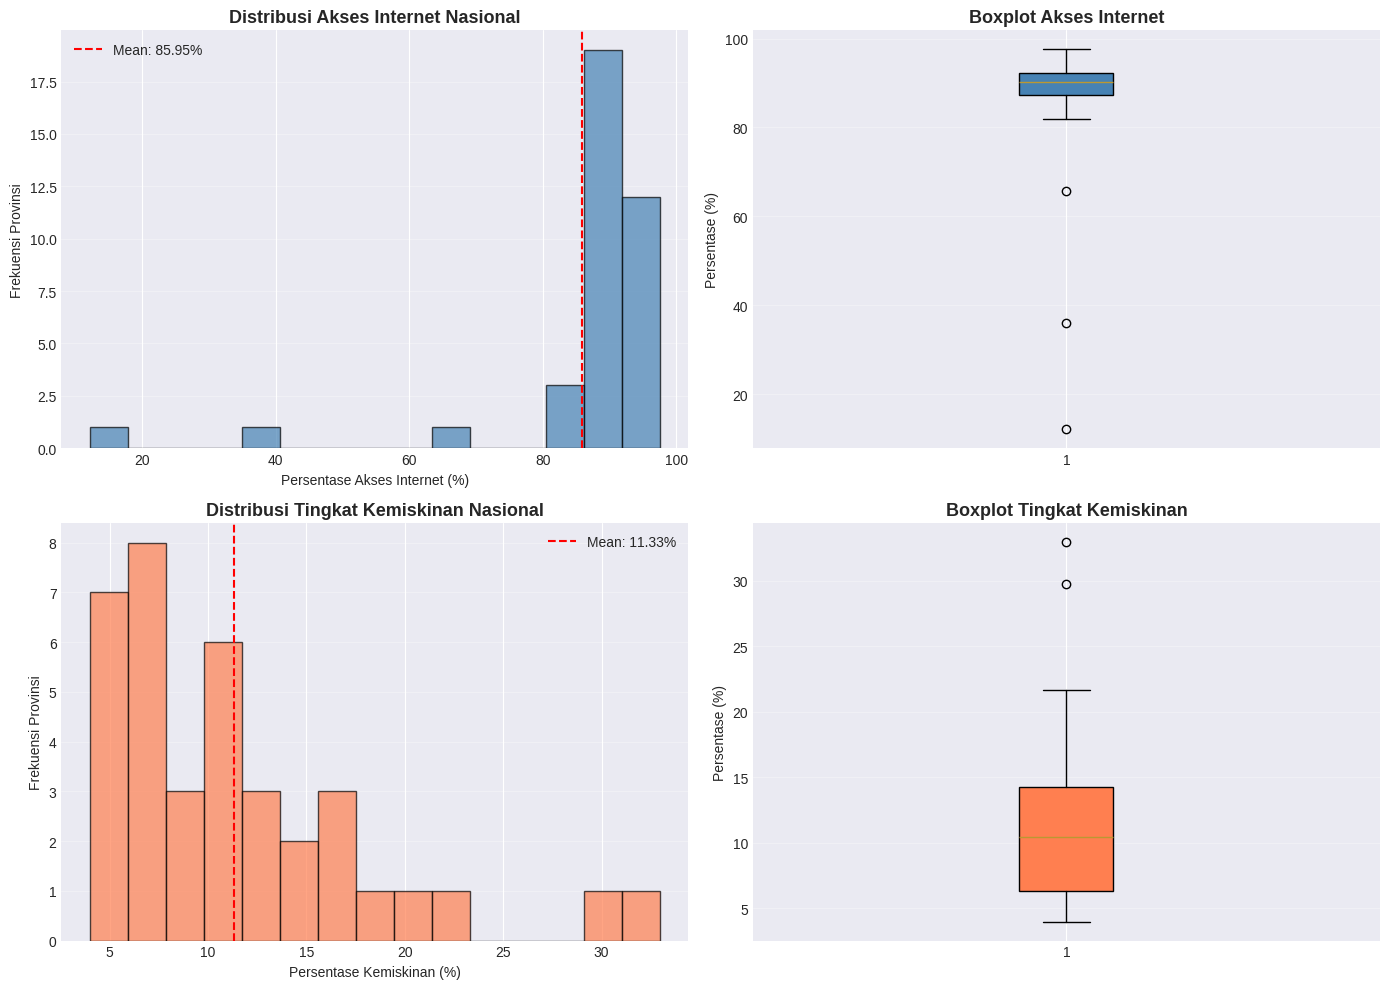


Statistik Univariate:
Akses Internet - Mean: 85.95%, Median: 90.17%, Std: 16.09%
Kemiskinan - Mean: 11.33%, Median: 10.47%, Std: 6.74%


3.3 Analisis Bivariate
--------------------------------------------------------------------------------


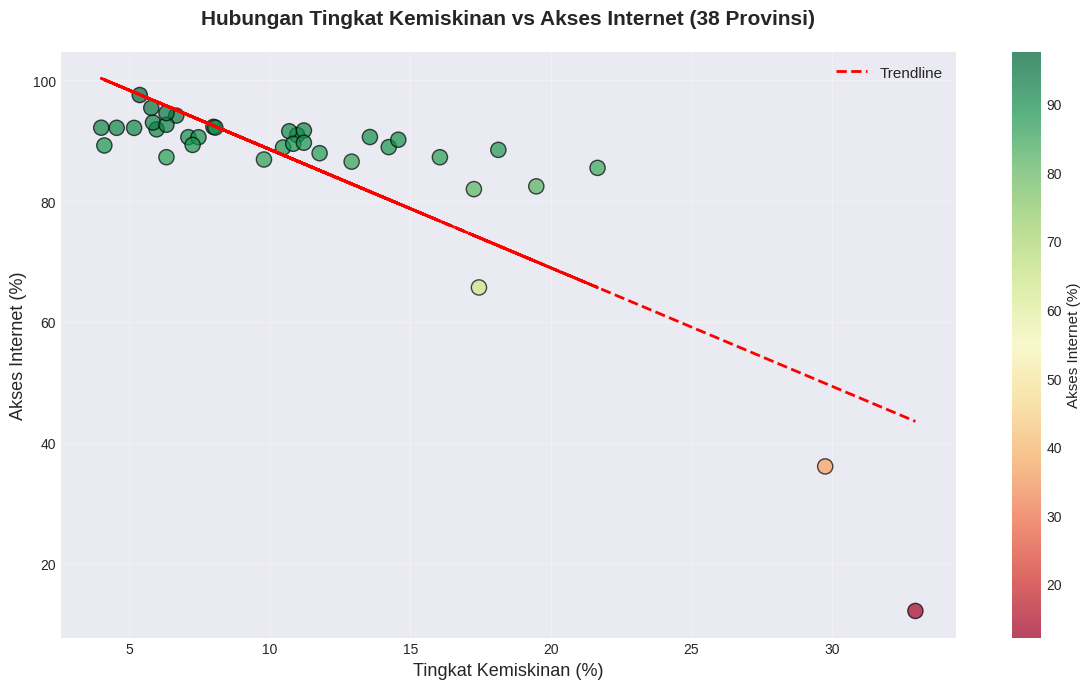


Korelasi Pearson: -0.8215
Interpretasi: Korelasi NEGATIF - Semakin tinggi kemiskinan, semakin rendah akses internet


In [ ]:
# ================================================================================
# BAGIAN 3: EKSPLORASI DATA
# ================================================================================

print("="*80)
print("BAGIAN 3: EKSPLORASI DATA")
print("="*80)

# --------------------------------------------------------------------------------
# 3.1 Statistik Deskriptif
# --------------------------------------------------------------------------------

print("\n3.1 Statistik Deskriptif")
print("-"*80)

print("\nStatistik Deskriptif Variabel Utama:")
print(df[['Internet_Total', 'Kemiskinan_Persen']].describe())

print("\nInformasi Dataset:")
df.info()

# --------------------------------------------------------------------------------
# 3.2 Analisis Univariate
# --------------------------------------------------------------------------------

print("\n\n3.2 Analisis Univariate")
print("-"*80)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram - Akses Internet
axes[0, 0].hist(df['Internet_Total'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribusi Akses Internet Nasional', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Persentase Akses Internet (%)')
axes[0, 0].set_ylabel('Frekuensi Provinsi')
axes[0, 0].axvline(df['Internet_Total'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df["Internet_Total"].mean():.2f}%')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Boxplot - Akses Internet
bp1 = axes[0, 1].boxplot(df['Internet_Total'], patch_artist=True)
bp1['boxes'][0].set_facecolor('steelblue')
axes[0, 1].set_title('Boxplot Akses Internet', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Persentase (%)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Histogram - Kemiskinan
axes[1, 0].hist(df['Kemiskinan_Persen'], bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_title('Distribusi Tingkat Kemiskinan Nasional', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Persentase Kemiskinan (%)')
axes[1, 0].set_ylabel('Frekuensi Provinsi')
axes[1, 0].axvline(df['Kemiskinan_Persen'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df["Kemiskinan_Persen"].mean():.2f}%')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Boxplot - Kemiskinan
bp2 = axes[1, 1].boxplot(df['Kemiskinan_Persen'], patch_artist=True)
bp2['boxes'][0].set_facecolor('coral')
axes[1, 1].set_title('Boxplot Tingkat Kemiskinan', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Persentase (%)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nStatistik Univariate:")
print(f"Akses Internet - Mean: {df['Internet_Total'].mean():.2f}%, Median: {df['Internet_Total'].median():.2f}%, Std: {df['Internet_Total'].std():.2f}%")
print(f"Kemiskinan - Mean: {df['Kemiskinan_Persen'].mean():.2f}%, Median: {df['Kemiskinan_Persen'].median():.2f}%, Std: {df['Kemiskinan_Persen'].std():.2f}%")

# --------------------------------------------------------------------------------
# 3.3 Analisis Bivariate
# --------------------------------------------------------------------------------

print("\n\n3.3 Analisis Bivariate")
print("-"*80)

# Scatter plot dengan trendline
plt.figure(figsize=(12, 7))

plt.scatter(df['Kemiskinan_Persen'], df['Internet_Total'],
            alpha=0.7, s=120, c=df['Internet_Total'], cmap='RdYlGn',
            edgecolors='black', linewidths=1)

# Trendline
z = np.polyfit(df['Kemiskinan_Persen'], df['Internet_Total'], 1)
p = np.poly1d(z)
plt.plot(df['Kemiskinan_Persen'], p(df['Kemiskinan_Persen']),
         "r--", linewidth=2, label='Trendline')

# Colorbar
cbar = plt.colorbar()
cbar.set_label('Akses Internet (%)', fontsize=11)

plt.title('Hubungan Tingkat Kemiskinan vs Akses Internet (38 Provinsi)',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tingkat Kemiskinan (%)', fontsize=13)
plt.ylabel('Akses Internet (%)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Korelasi Pearson
correlation = df['Kemiskinan_Persen'].corr(df['Internet_Total'])
print(f"\nKorelasi Pearson: {correlation:.4f}")

if correlation < 0:
    print("Interpretasi: Korelasi NEGATIF - Semakin tinggi kemiskinan, semakin rendah akses internet")
else:
    print("Interpretasi: Korelasi POSITIF - Semakin tinggi kemiskinan, semakin tinggi akses internet")

In [ ]:
# --------------------------------------------------------------------------------
# 3.4 Analisis Top & Bottom Provinsi
# --------------------------------------------------------------------------------

print("3.4 Analisis Top & Bottom Provinsi")
print("-"*80)

print("\nTOP 5 PROVINSI - AKSES INTERNET TERTINGGI")
print("-"*80)
top5_internet = df.nlargest(5, 'Internet_Total')[['Provinsi', 'Internet_Total', 'Kemiskinan_Persen']]
print(top5_internet.to_string(index=False))

print("\n\nBOTTOM 5 PROVINSI - AKSES INTERNET TERENDAH")
print("-"*80)
bottom5_internet = df.nsmallest(5, 'Internet_Total')[['Provinsi', 'Internet_Total', 'Kemiskinan_Persen']]
print(bottom5_internet.to_string(index=False))

print("\n\nTOP 5 PROVINSI - TINGKAT KEMISKINAN TERTINGGI")
print("-"*80)
top5_poverty = df.nlargest(5, 'Kemiskinan_Persen')[['Provinsi', 'Kemiskinan_Persen', 'Internet_Total']]
print(top5_poverty.to_string(index=False))

print("\n\nBOTTOM 5 PROVINSI - TINGKAT KEMISKINAN TERENDAH")
print("-"*80)
bottom5_poverty = df.nsmallest(5, 'Kemiskinan_Persen')[['Provinsi', 'Kemiskinan_Persen', 'Internet_Total']]
print(bottom5_poverty.to_string(index=False))

# --------------------------------------------------------------------------------
# 3.5 Deteksi Outliers
# --------------------------------------------------------------------------------

print("\n\n3.5 Deteksi Outliers")
print("-"*80)

# Z-score method
z_internet = np.abs(stats.zscore(df['Internet_Total']))
outliers_internet = df[z_internet > 3]

print(f"\nOutliers Akses Internet (Z-score > 3):")
if len(outliers_internet) > 0:
    print(outliers_internet[['Provinsi', 'Internet_Total']].to_string(index=False))
else:
    print("Tidak ada outliers ekstrem")

z_kemiskinan = np.abs(stats.zscore(df['Kemiskinan_Persen']))
outliers_kemiskinan = df[z_kemiskinan > 3]

print(f"\nOutliers Tingkat Kemiskinan (Z-score > 3):")
if len(outliers_kemiskinan) > 0:
    print(outliers_kemiskinan[['Provinsi', 'Kemiskinan_Persen']].to_string(index=False))
else:
    print("Tidak ada outliers ekstrem")

# --------------------------------------------------------------------------------
# Ringkasan
# --------------------------------------------------------------------------------

print("\n" + "="*80)
print("RINGKASAN")
print("="*80)
print(f"Jumlah provinsi: {len(df)}")
print(f"Akses Internet - Range: {df['Internet_Total'].min():.2f}% - {df['Internet_Total'].max():.2f}%")
print(f"Kemiskinan - Range: {df['Kemiskinan_Persen'].min():.2f}% - {df['Kemiskinan_Persen'].max():.2f}%")
print(f"Korelasi: {correlation:.4f}")
print("="*80)

3.4 Analisis Top & Bottom Provinsi
--------------------------------------------------------------------------------

TOP 5 PROVINSI - AKSES INTERNET TERTINGGI
--------------------------------------------------------------------------------
        Provinsi  Internet_Total  Kemiskinan_Persen
       KEP. RIAU           97.57               5.37
KALIMANTAN TIMUR           95.45               5.78
KALIMANTAN UTARA           94.58               6.32
            RIAU           94.16               6.67
          BANTEN           93.02               5.84


BOTTOM 5 PROVINSI - AKSES INTERNET TERENDAH
--------------------------------------------------------------------------------
           Provinsi  Internet_Total  Kemiskinan_Persen
   PAPUA PEGUNUNGAN           12.15              32.97
       PAPUA TENGAH           36.08              29.76
      PAPUA SELATAN           65.71              17.44
              PAPUA           81.99              17.26
NUSA TENGGARA TIMUR           82.45           

## **4. Pendefinisian & Kategorisasi Variabel**

In [ ]:
# ================================================================================
# BAGIAN 4: MENENTUKAN VARIABEL Y DAN KATEGORISASI VARIABEL
# ================================================================================

print("="*80)
print("BAGIAN 4: MENENTUKAN VARIABEL Y DAN KATEGORISASI VARIABEL")
print("="*80)

# --------------------------------------------------------------------------------
# 4.1 Penentuan Variabel Penelitian
# --------------------------------------------------------------------------------

print("\n4.1 Penentuan Variabel Penelitian")
print("-"*80)

print("\nVariabel Dependen (Y):")
print("  - Internet_Total: Persentase akses internet per provinsi")
print("\nVariabel Independen (X):")
print("  - Kemiskinan_Persen: Persentase penduduk miskin per provinsi")

# --------------------------------------------------------------------------------
# 4.2 Kategorisasi Variabel Akses Internet
# --------------------------------------------------------------------------------

print("\n\n4.2 Kategorisasi Variabel Akses Internet")
print("-"*80)

# Hitung quartile
q25_internet = df['Internet_Total'].quantile(0.25)
q75_internet = df['Internet_Total'].quantile(0.75)

def kategorisasi_internet(nilai):
    if nilai < q25_internet:
        return 'Rendah'
    elif nilai < q75_internet:
        return 'Sedang'
    else:
        return 'Tinggi'

df['Kategori_Internet'] = df['Internet_Total'].apply(kategorisasi_internet)

print(f"Metode kategorisasi: Berdasarkan kuartil")
print(f"\nBatas kategori:")
print(f"  - Rendah  : < {q25_internet:.2f}%")
print(f"  - Sedang  : {q25_internet:.2f}% - {q75_internet:.2f}%")
print(f"  - Tinggi  : > {q75_internet:.2f}%")

print(f"\nDistribusi kategori:")
print(df['Kategori_Internet'].value_counts().sort_index())

# --------------------------------------------------------------------------------
# 4.3 Kategorisasi Variabel Kemiskinan
# --------------------------------------------------------------------------------

print("\n\n4.3 Kategorisasi Variabel Kemiskinan")
print("-"*80)

# Hitung quartile
q25_poverty = df['Kemiskinan_Persen'].quantile(0.25)
q75_poverty = df['Kemiskinan_Persen'].quantile(0.75)

def kategorisasi_kemiskinan(nilai):
    if nilai < q25_poverty:
        return 'Rendah'
    elif nilai < q75_poverty:
        return 'Sedang'
    else:
        return 'Tinggi'

df['Kategori_Kemiskinan'] = df['Kemiskinan_Persen'].apply(kategorisasi_kemiskinan)

print(f"Metode kategorisasi: Berdasarkan kuartil")
print(f"\nBatas kategori:")
print(f"  - Rendah  : < {q25_poverty:.2f}%")
print(f"  - Sedang  : {q25_poverty:.2f}% - {q75_poverty:.2f}%")
print(f"  - Tinggi  : > {q75_poverty:.2f}%")

print(f"\nDistribusi kategori:")
print(df['Kategori_Kemiskinan'].value_counts().sort_index())

BAGIAN 4: MENENTUKAN VARIABEL Y DAN KATEGORISASI VARIABEL

4.1 Penentuan Variabel Penelitian
--------------------------------------------------------------------------------

Variabel Dependen (Y):
  - Internet_Total: Persentase akses internet per provinsi

Variabel Independen (X):
  - Kemiskinan_Persen: Persentase penduduk miskin per provinsi


4.2 Kategorisasi Variabel Akses Internet
--------------------------------------------------------------------------------
Metode kategorisasi: Berdasarkan kuartil

Batas kategori:
  - Rendah  : < 87.28%
  - Sedang  : 87.28% - 92.14%
  - Tinggi  : > 92.14%

Distribusi kategori:
Kategori_Internet
Rendah     9
Sedang    18
Tinggi    10
Name: count, dtype: int64


4.3 Kategorisasi Variabel Kemiskinan
--------------------------------------------------------------------------------
Metode kategorisasi: Berdasarkan kuartil

Batas kategori:
  - Rendah  : < 6.32%
  - Sedang  : 6.32% - 14.23%
  - Tinggi  : > 14.23%

Distribusi kategori:
Kategori_Kemiskin

4.4 Crosstabulation
--------------------------------------------------------------------------------

Tabel Kontingensi (Frekuensi):
Kategori_Internet    Rendah  Sedang  Tinggi
Kategori_Kemiskinan                        
Rendah                    0       3       5
Sedang                    2      12       5
Tinggi                    7       3       0

Tabel Kontingensi (Persentase per Baris):
Kategori_Internet    Rendah  Sedang  Tinggi
Kategori_Kemiskinan                        
Rendah                 0.00   37.50   62.50
Sedang                10.53   63.16   26.32
Tinggi                70.00   30.00    0.00


4.5 Visualisasi
--------------------------------------------------------------------------------


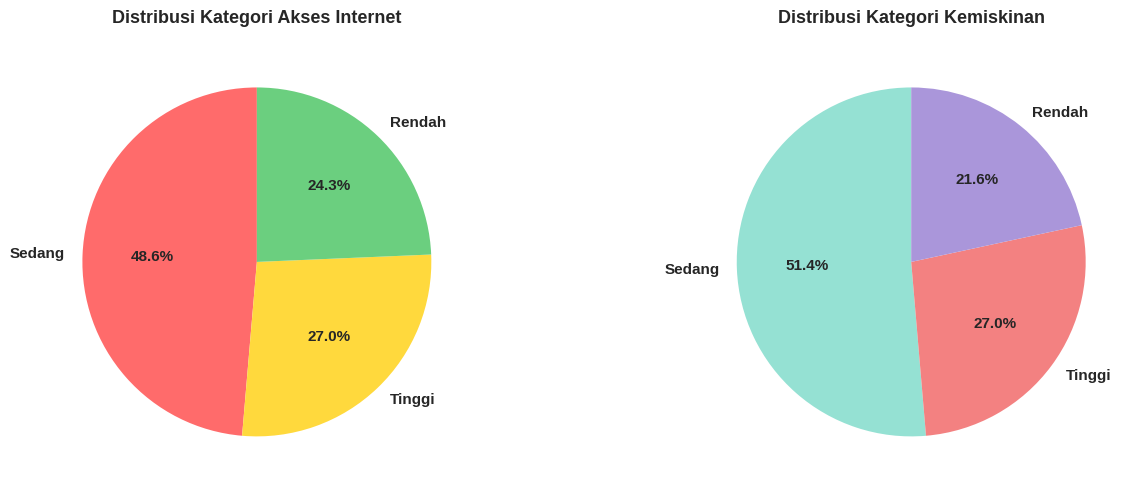

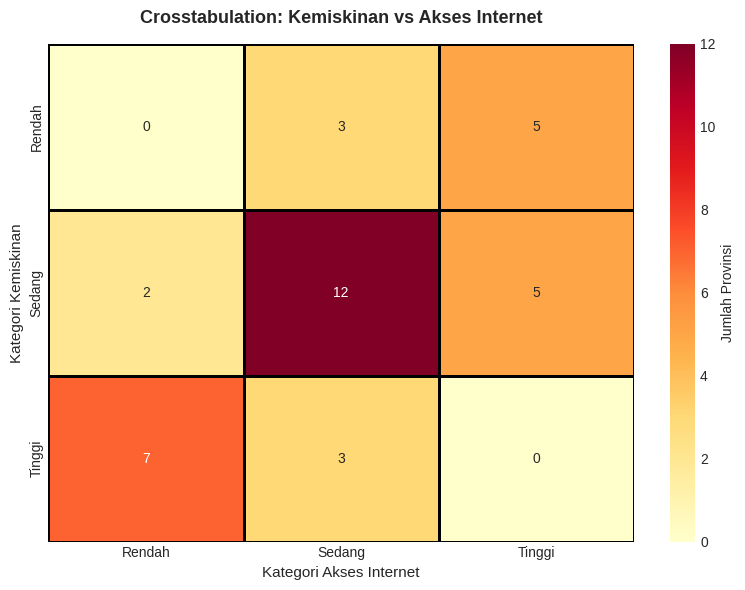


RINGKASAN
Variabel Dependen (Y): Internet_Total
Variabel Independen (X): Kemiskinan_Persen

Kategori Akses Internet:
  Rendah: 9 provinsi
  Sedang: 18 provinsi
  Tinggi: 10 provinsi

Kategori Kemiskinan:
  Rendah: 8 provinsi
  Sedang: 19 provinsi
  Tinggi: 10 provinsi


In [ ]:
# --------------------------------------------------------------------------------
# 4.4 Crosstabulation
# --------------------------------------------------------------------------------

print("4.4 Crosstabulation")
print("-"*80)

crosstab = pd.crosstab(df['Kategori_Kemiskinan'], df['Kategori_Internet'])

print("\nTabel Kontingensi (Frekuensi):")
print(crosstab)

# Persentase per baris
crosstab_pct = pd.crosstab(df['Kategori_Kemiskinan'], df['Kategori_Internet'], normalize='index') * 100

print("\nTabel Kontingensi (Persentase per Baris):")
print(crosstab_pct.round(2))

# --------------------------------------------------------------------------------
# 4.5 Visualisasi
# --------------------------------------------------------------------------------

print("\n\n4.5 Visualisasi")
print("-"*80)

# Visualisasi 1: Pie Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart - Kategori Internet
kategori_internet_counts = df['Kategori_Internet'].value_counts()
colors1 = ['#ff6b6b', '#ffd93d', '#6bcf7f']
axes[0].pie(kategori_internet_counts, labels=kategori_internet_counts.index,
            autopct='%1.1f%%', colors=colors1, startangle=90,
            textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title('Distribusi Kategori Akses Internet', fontsize=13, fontweight='bold', pad=15)

# Pie chart - Kategori Kemiskinan
kategori_poverty_counts = df['Kategori_Kemiskinan'].value_counts()
colors2 = ['#95e1d3', '#f38181', '#aa96da']
axes[1].pie(kategori_poverty_counts, labels=kategori_poverty_counts.index,
            autopct='%1.1f%%', colors=colors2, startangle=90,
            textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Distribusi Kategori Kemiskinan', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Visualisasi 2: Heatmap Crosstabulation
print("\n")
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Jumlah Provinsi'},
            linewidths=1, linecolor='black')
plt.title('Crosstabulation: Kemiskinan vs Akses Internet', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Kategori Akses Internet', fontsize=11)
plt.ylabel('Kategori Kemiskinan', fontsize=11)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------
# Ringkasan
# --------------------------------------------------------------------------------

print("\n" + "="*80)
print("RINGKASAN")
print("="*80)
print(f"Variabel Dependen (Y): Internet_Total")
print(f"Variabel Independen (X): Kemiskinan_Persen")
print(f"\nKategori Akses Internet:")
print(f"  Rendah: {len(df[df['Kategori_Internet']=='Rendah'])} provinsi")
print(f"  Sedang: {len(df[df['Kategori_Internet']=='Sedang'])} provinsi")
print(f"  Tinggi: {len(df[df['Kategori_Internet']=='Tinggi'])} provinsi")
print(f"\nKategori Kemiskinan:")
print(f"  Rendah: {len(df[df['Kategori_Kemiskinan']=='Rendah'])} provinsi")
print(f"  Sedang: {len(df[df['Kategori_Kemiskinan']=='Sedang'])} provinsi")
print(f"  Tinggi: {len(df[df['Kategori_Kemiskinan']=='Tinggi'])} provinsi")
print("="*80)

## **5. Pemodelan Prediktif & Uji Korelasi**

In [ ]:
# ================================================================================
# BAGIAN 5: ANALISIS REGRESI UNTUK SIGNIFIKANSI KORELASI
# ================================================================================

print("="*80)
print("BAGIAN 5: ANALISIS REGRESI UNTUK SIGNIFIKANSI KORELASI")
print("="*80)

# --------------------------------------------------------------------------------
# 5.1 Persiapan Data Regresi
# --------------------------------------------------------------------------------

print("\n5.1 Persiapan Data Regresi")
print("-"*80)

# Sistem prioritas kolom numerik
kemiskinan_col = None
internet_col = None

# Daftar prioritas kolom (dari yang paling diinginkan)
kemiskinan_priority = ['Kemiskinan_Persen', 'Persentase_Kemiskinan', 'kemiskinan']
internet_priority = ['Internet_Total', 'Persentase_Internet', 'internet_total', 'internet']

# Cari kolom kemiskinan
for priority_name in kemiskinan_priority:
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            col_lower = col.lower()
            if priority_name.lower() in col_lower:
                if 'kategori' not in col_lower and 'binary' not in col_lower:
                    kemiskinan_col = col
                    break
    if kemiskinan_col is not None:
        break

# Cari kolom internet - PRIORITASKAN yang 'Total'
for priority_name in internet_priority:
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            col_lower = col.lower()
            if priority_name.lower() in col_lower:
                if 'kategori' not in col_lower and 'binary' not in col_lower:
                    internet_col = col
                    break
    if internet_col is not None:
        break

# Validasi
if kemiskinan_col is None or internet_col is None:
    print("ERROR: Kolom numerik tidak ditemukan!")
    print("\nKolom numerik yang tersedia:")
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            print(f"  - {col}")
    raise ValueError("Kolom tidak ditemukan")

print(f"Kolom yang digunakan:")
print(f"  Kemiskinan (X): {kemiskinan_col} (dtype: {df[kemiskinan_col].dtype})")
print(f"  Internet (Y): {internet_col} (dtype: {df[internet_col].dtype})")

# Pastikan tidak ada missing values
df_clean = df[[kemiskinan_col, internet_col]].dropna()

print(f"\nJumlah data: {len(df_clean)} provinsi")
print(f"Variabel:")
print(f"  X (Independent): {kemiskinan_col}")
print(f"  Y (Dependent): {internet_col}")

# Statistik deskriptif
print(f"\nStatistik Deskriptif:")
print(f"  Kemiskinan - Mean: {df_clean[kemiskinan_col].mean():.2f}%, SD: {df_clean[kemiskinan_col].std():.2f}%")
print(f"  Internet   - Mean: {df_clean[internet_col].mean():.2f}%, SD: {df_clean[internet_col].std():.2f}%")
print(f"  Kemiskinan - Range: [{df_clean[kemiskinan_col].min():.2f}%, {df_clean[kemiskinan_col].max():.2f}%]")
print(f"  Internet   - Range: [{df_clean[internet_col].min():.2f}%, {df_clean[internet_col].max():.2f}%]")

# --------------------------------------------------------------------------------
# 5.2 Korelasi Pearson
# --------------------------------------------------------------------------------

print("\n\n5.2 Korelasi Pearson")
print("-"*80)

# Hitung korelasi dengan p-value
r_pearson, p_pearson = stats.pearsonr(df_clean[kemiskinan_col],
                                       df_clean[internet_col])

print(f"\nKoefisien Korelasi Pearson (r):")
print(f"  r = {r_pearson:.4f}")
print(f"  r² = {r_pearson**2:.4f}")
print(f"  p-value = {p_pearson:.6f}")

# Interpretasi kekuatan korelasi (Cohen, 1988)
print("\nInterpretasi Kekuatan Korelasi (Cohen, 1988):")
print("  |r| < 0.10  : Sangat Lemah (Negligible)")
print("  0.10-0.30   : Lemah (Weak)")
print("  0.30-0.50   : Sedang (Moderate)")
print("  0.50-0.70   : Kuat (Strong)")
print("  |r| > 0.70  : Sangat Kuat (Very Strong)")

abs_r = abs(r_pearson)
if abs_r < 0.10:
    corr_strength = "SANGAT LEMAH"
elif abs_r < 0.30:
    corr_strength = "LEMAH"
elif abs_r < 0.50:
    corr_strength = "SEDANG"
elif abs_r < 0.70:
    corr_strength = "KUAT"
else:
    corr_strength = "SANGAT KUAT"

direction = "NEGATIF" if r_pearson < 0 else "POSITIF"

print(f"\nKesimpulan Korelasi:")
print(f"  Kekuatan: {corr_strength}")
print(f"  Arah: {direction}")
print(f"  Signifikansi: {'SIGNIFIKAN' if p_pearson < 0.05 else 'TIDAK SIGNIFIKAN'} (α = 0.05)")

if r_pearson < 0:
    print(f"\n  Interpretasi:")
    print(f"  Terdapat korelasi {direction} yang {corr_strength} antara tingkat")
    print(f"  kemiskinan dan akses internet. Semakin TINGGI persentase kemiskinan,")
    print(f"  semakin RENDAH persentase akses internet (dan sebaliknya).")
else:
    print(f"\n  Interpretasi:")
    print(f"  Terdapat korelasi {direction} yang {corr_strength} antara tingkat")
    print(f"  kemiskinan dan akses internet. Semakin TINGGI persentase kemiskinan,")
    print(f"  semakin TINGGI pula persentase akses internet (dan sebaliknya).")

# Uji signifikansi
print(f"\nUji Signifikansi Korelasi:")
print(f"  H₀: ρ = 0 (Tidak ada korelasi linear)")
print(f"  H₁: ρ ≠ 0 (Ada korelasi linear)")
print(f"  p-value = {p_pearson:.6f}")

if p_pearson < 0.05:
    print(f"  Keputusan: TOLAK H₀")
    print(f"  Kesimpulan: Korelasi SIGNIFIKAN secara statistik (p < 0.05)")
else:
    print(f"  Keputusan: GAGAL TOLAK H₀")
    print(f"  Kesimpulan: Korelasi TIDAK SIGNIFIKAN secara statistik (p ≥ 0.05)")

# --------------------------------------------------------------------------------
# 5.3 Model Regresi Linear
# --------------------------------------------------------------------------------

print("\n\n5.3 Model Regresi Linear")
print("-"*80)

# Persiapan data untuk regresi
X = df_clean[kemiskinan_col].values.reshape(-1, 1)
y = df_clean[internet_col].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Prediksi
y_pred = model.predict(X)

# Koefisien
intercept = model.intercept_
slope = model.coef_[0]
r2 = r2_score(y, y_pred)

# Hasil regresi
print(f"\nParameter Regresi:")
print(f"  Intercept (β₀): {intercept:.4f}")
print(f"  Coefficient (β₁): {slope:.4f}")
print(f"  R² Score: {r2:.4f}")

print(f"\nPersamaan Regresi:")
print(f"  Ŷ = {intercept:.4f} + ({slope:.4f}) × X")
print(f"  {internet_col} = {intercept:.4f} + ({slope:.4f}) × {kemiskinan_col}")

# Interpretasi koefisien dengan warning
print(f"\nInterpretasi Koefisien:")
print(f"  Intercept (b₀) = {intercept:.4f}")

# CEK APAKAH INTERCEPT REALISTIS
if intercept > 100 or intercept < 0:
    print(f"    ⚠️  CATATAN: Nilai intercept ({intercept:.2f}%) di luar rentang 0-100%.")
    print(f"    Ini karena {kemiskinan_col} = 0% berada DI LUAR rentang data observasi")
    print(f"    (range data: {df_clean[kemiskinan_col].min():.2f}% - {df_clean[kemiskinan_col].max():.2f}%).")
    print(f"    Intercept tidak memiliki makna substantif dalam konteks ini.")
    print(f"    Model HANYA VALID untuk memprediksi dalam rentang data yang diamati.")
else:
    print(f"    → Ketika {kemiskinan_col} = 0%, prediksi {internet_col} = {intercept:.2f}%")

print(f"\n  Slope (b₁) = {slope:.4f}")
if slope < 0:
    print(f"    → Setiap kenaikan 1% kemiskinan, akses internet turun {abs(slope):.2f}%")
    print(f"    → Ini adalah interpretasi yang VALID dalam rentang data yang diamati.")
else:
    print(f"    → Setiap kenaikan 1% kemiskinan, akses internet naik {slope:.2f}%")
    print(f"    → Ini adalah interpretasi yang VALID dalam rentang data yang diamati.")

# Contoh prediksi dalam rentang data
print(f"\nContoh Prediksi (dalam rentang data):")
print("-"*40)
print(f"{'Kemiskinan (%)':>15} | {'Prediksi Internet (%)':>22}")
print("-"*40)

# Buat range prediksi
min_kemiskinan = df_clean[kemiskinan_col].min()
max_kemiskinan = df_clean[kemiskinan_col].max()
prediction_values = np.linspace(min_kemiskinan, max_kemiskinan, 5)

for k_val in prediction_values:
    pred_val = intercept + slope * k_val
    print(f"{k_val:>15.2f} | {pred_val:>22.2f}")

print("-"*40)

# Hubungan r dan R²
print(f"\nHubungan Korelasi Pearson (r) dan Koefisien Determinasi (R²):")
print(f"  r = {r_pearson:.4f}")
print(f"  r² = {r_pearson**2:.4f}")
print(f"  R² = {r2:.4f}")
print(f"  Catatan: Untuk regresi linear sederhana, r² = R²")

# --------------------------------------------------------------------------------
# 5.4 Uji Signifikansi Model (F-Test)
# --------------------------------------------------------------------------------

print("\n\n5.4 Uji Signifikansi Model (F-Test)")
print("-"*80)

print("\nUji F menguji signifikansi model regresi secara KESELURUHAN.")
print("Untuk regresi linear sederhana, ini ekuivalen dengan uji t koefisien.")

# Hitung komponen ANOVA
n = len(y)
k = 1  # jumlah prediktor

# Sum of Squares
ss_total = np.sum((y - np.mean(y))**2)
ss_regression = np.sum((y_pred - np.mean(y))**2)
ss_residual = np.sum((y - y_pred)**2)

# Degrees of Freedom
df_regression = k
df_residual = n - k - 1
df_total = n - 1

# Mean Squares
ms_regression = ss_regression / df_regression
ms_residual = ss_residual / df_residual

# F-statistic
f_stat = ms_regression / ms_residual
p_f = 1 - stats.f.cdf(f_stat, df_regression, df_residual)

print("\nTabel ANOVA:")
print("="*80)
print(f"{'Source':20} {'df':>8} {'Sum of Squares':>18} {'Mean Square':>15} {'F':>10} {'p-value':>10}")
print("="*80)
print(f"{'Regression':20} {df_regression:>8} {ss_regression:>18.4f} {ms_regression:>15.4f} {f_stat:>10.4f} {p_f:>10.6f}")
print(f"{'Residual':20} {df_residual:>8} {ss_residual:>18.4f} {ms_residual:>15.4f}")
print(f"{'Total':20} {df_total:>8} {ss_total:>18.4f}")
print("="*80)

print(f"\nHipotesis:")
print(f"  H₀: Model tidak signifikan (β₁ = 0)")
print(f"  H₁: Model signifikan (β₁ ≠ 0)")

print(f"\nHasil Uji F:")
print(f"  F-statistic = {f_stat:.4f}")
print(f"  df₁ (regression) = {df_regression}")
print(f"  df₂ (residual) = {df_residual}")
print(f"  p-value = {p_f:.6f}")
print(f"  Critical value (α=0.05) = {stats.f.ppf(0.95, df_regression, df_residual):.4f}")

if p_f < 0.05:
    print(f"\nKeputusan: TOLAK H₀")
    print(f"Kesimpulan: Model regresi SIGNIFIKAN secara statistik (p < 0.05)")
else:
    print(f"\nKeputusan: GAGAL TOLAK H₀")
    print(f"Kesimpulan: Model regresi TIDAK signifikan secara statistik (p ≥ 0.05)")

# Interpretasi R²
print(f"\nInterpretasi Goodness of Fit (R²):")
print(f"  R² = {r2:.4f} ({r2*100:.2f}%)")
print(f"  Interpretasi: Model dapat menjelaskan {r2*100:.2f}% variasi dalam")
print(f"  akses internet berdasarkan tingkat kemiskinan.")
print(f"  Sisanya ({(1-r2)*100:.2f}%) dijelaskan oleh faktor lain yang tidak")
print(f"  termasuk dalam model (infrastruktur, kebijakan, geografi, pendidikan, dll).")

# Adjusted R²
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print(f"\nAdjusted R²:")
print(f"  Adjusted R² = {adj_r2:.4f}")
print(f"  Catatan: Adjusted R² menyesuaikan untuk jumlah prediktor dalam model.")
print(f"  Untuk regresi sederhana (1 prediktor), perbedaannya minimal.")

# Hubungan F dan t²
from scipy.stats import t as t_dist

# Hitung t-statistic untuk koefisien (akan dihitung lagi di 5.5)
residuals = y - y_pred
mse = np.sum(residuals**2) / df_residual
se_beta = np.sqrt(mse / np.sum((X - X.mean())**2))
t_stat = slope / se_beta

print(f"\nHubungan F-test dan t-test:")
print(f"  Untuk regresi linear SEDERHANA (1 prediktor):")
print(f"  F = t²")
print(f"  F = {f_stat:.4f}")
print(f"  t² = {t_stat**2:.4f}")
print(f"  Verifikasi: F ≈ t² → {np.isclose(f_stat, t_stat**2)}")

BAGIAN 5: ANALISIS REGRESI UNTUK SIGNIFIKANSI KORELASI

5.1 Persiapan Data Regresi
--------------------------------------------------------------------------------
Kolom yang digunakan:
  Kemiskinan (X): Kemiskinan_Persen (dtype: float64)
  Internet (Y): Internet_Total (dtype: float64)

Jumlah data: 37 provinsi
Variabel:
  X (Independent): Kemiskinan_Persen
  Y (Dependent): Internet_Total

Statistik Deskriptif:
  Kemiskinan - Mean: 11.33%, SD: 6.74%
  Internet   - Mean: 85.95%, SD: 16.09%
  Kemiskinan - Range: [4.00%, 32.97%]
  Internet   - Range: [12.15%, 97.57%]


5.2 Korelasi Pearson
--------------------------------------------------------------------------------

Koefisien Korelasi Pearson (r):
  r = -0.8215
  r² = 0.6748
  p-value = 0.000000

Interpretasi Kekuatan Korelasi (Cohen, 1988):
  |r| < 0.10  : Sangat Lemah (Negligible)
  0.10-0.30   : Lemah (Weak)
  0.30-0.50   : Sedang (Moderate)
  0.50-0.70   : Kuat (Strong)
  |r| > 0.70  : Sangat Kuat (Very Strong)

Kesimpulan Korelas

5.5 Uji Signifikansi Koefisien (t-Test)
--------------------------------------------------------------------------------

Uji t menguji signifikansi SETIAP KOEFISIEN secara individual.
Untuk regresi sederhana, ini ekuivalen dengan uji F model.

Hipotesis:
  H₀: β₁ = 0 (Tidak ada pengaruh kemiskinan terhadap akses internet)
  H₁: β₁ ≠ 0 (Ada pengaruh kemiskinan terhadap akses internet)

Hasil Uji t:
  Koefisien (β₁): -1.9603
  Standard Error: 0.2300
  t-statistic: -8.5219
  p-value: 0.000000
  Degrees of freedom: 35
  Critical value (α=0.05, two-tailed): ±2.0301

Keputusan: TOLAK H₀
Kesimpulan: Tingkat kemiskinan BERPENGARUH SIGNIFIKAN terhadap akses internet (p < 0.05)

Confidence Interval 95% untuk β₁:
  [-2.4273, -1.4933]
  Interpretasi: Dengan 95% confidence, setiap kenaikan 1% kemiskinan
  dikaitkan dengan penurunan akses internet antara 1.4933% hingga 2.4273%.

Interpretasi Praktis:
  Setiap kenaikan 1% tingkat kemiskinan dikaitkan dengan penurunan
  1.9603% dalam akses internet.


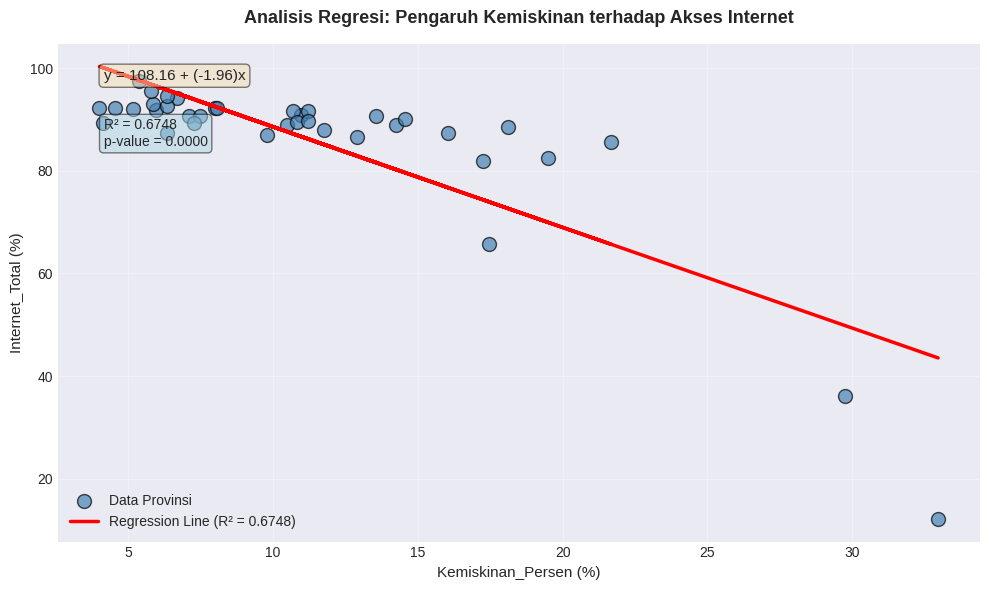



5.7 Uji Asumsi Regresi
--------------------------------------------------------------------------------

Asumsi klasik regresi linear (OLS):
  1. Linearitas: Hubungan antara X dan Y bersifat linear
  2. Independensi: Observasi saling independen
  3. Homoskedastisitas: Variansi residual konstan
  4. Normalitas: Residual berdistribusi normal
  5. Tidak ada multikolinearitas (tidak relevan untuk regresi sederhana)

(1) Uji Normalitas Residual (Shapiro-Wilk Test)
    H₀: Residual berdistribusi normal
    W-statistic: 0.9494
    p-value: 0.092351
    Status: Asumsi TERPENUHI (p > 0.05)

(2) Uji Homoskedastisitas (Breusch-Pagan Test)
    H₀: Homoskedastisitas (variansi residual konstan)
    LM statistic: 20.4326
    p-value: 0.000006
    Status: Asumsi TIDAK terpenuhi (p < 0.05)
    Rekomendasi: Gunakan robust standard errors atau transformasi data

(3) Uji Autokorelasi (Durbin-Watson Test)
    Durbin-Watson statistic: 1.0366
    Interpretasi: DW ≈ 2 menunjukkan tidak ada autokorelasi
    

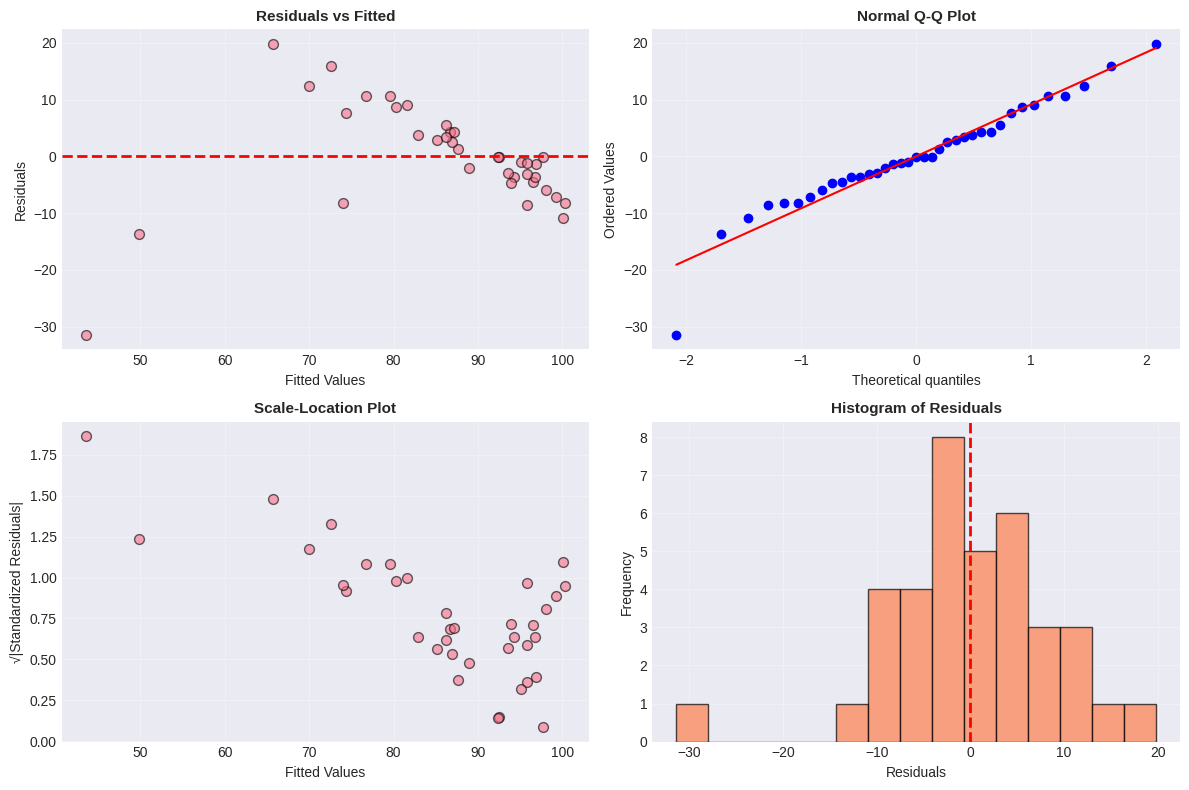


RINGKASAN

1. Korelasi Pearson:
   r = -0.8215 (SANGAT KUAT, NEGATIF)
   p-value = 0.000000
   Signifikan: YA

2. Model Regresi:
   Persamaan: Y = 108.1643 + (-1.9603)X
   R² = 0.6748 (67.48%)
   Adjusted R² = 0.6655

3. Uji Signifikansi Model (F-Test):
   F-statistic = 72.6233
   p-value = 0.000000
   Signifikan: YA

4. Uji Signifikansi Koefisien (t-Test):
   t-statistic = -8.5219
   p-value = 0.000000
   Signifikan: YA
   CI 95%: [-2.4273, -1.4933]

5. Asumsi Regresi:
   Normalitas: Terpenuhi
   Homoskedastisitas: Tidak terpenuhi
   No Autokorelasi: Tidak terpenuhi

6. Interpretasi:
   Setiap kenaikan 1% kemiskinan → penurunan 1.9603% akses internet
   Model menjelaskan 67.48% variasi dalam akses internet


In [ ]:
# --------------------------------------------------------------------------------
# 5.5 Uji Signifikansi Koefisien (t-Test)
# --------------------------------------------------------------------------------

print("5.5 Uji Signifikansi Koefisien (t-Test)")
print("-"*80)

print("\nUji t menguji signifikansi SETIAP KOEFISIEN secara individual.")
print("Untuk regresi sederhana, ini ekuivalen dengan uji F model.")

# t-statistic sudah dihitung di atas
p_value_coef = 2 * (1 - t_dist.cdf(abs(t_stat), df_residual))

print(f"\nHipotesis:")
print(f"  H₀: β₁ = 0 (Tidak ada pengaruh kemiskinan terhadap akses internet)")
print(f"  H₁: β₁ ≠ 0 (Ada pengaruh kemiskinan terhadap akses internet)")

print(f"\nHasil Uji t:")
print(f"  Koefisien (β₁): {slope:.4f}")
print(f"  Standard Error: {se_beta:.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value_coef:.6f}")
print(f"  Degrees of freedom: {df_residual}")
print(f"  Critical value (α=0.05, two-tailed): ±{t_dist.ppf(0.975, df_residual):.4f}")

if p_value_coef < 0.05:
    print(f"\nKeputusan: TOLAK H₀")
    print(f"Kesimpulan: Tingkat kemiskinan BERPENGARUH SIGNIFIKAN terhadap akses internet (p < 0.05)")
else:
    print(f"\nKeputusan: GAGAL TOLAK H₀")
    print(f"Kesimpulan: Tingkat kemiskinan TIDAK berpengaruh signifikan terhadap akses internet (p ≥ 0.05)")

# Confidence Interval
ci_margin = t_dist.ppf(0.975, df_residual) * se_beta
ci_lower = slope - ci_margin
ci_upper = slope + ci_margin

print(f"\nConfidence Interval 95% untuk β₁:")
print(f"  [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  Interpretasi: Dengan 95% confidence, setiap kenaikan 1% kemiskinan")
if slope < 0:
    print(f"  dikaitkan dengan penurunan akses internet antara {abs(ci_upper):.4f}% hingga {abs(ci_lower):.4f}%.")
else:
    print(f"  dikaitkan dengan peningkatan akses internet antara {ci_lower:.4f}% hingga {ci_upper:.4f}%.")

# Interpretasi koefisien
print(f"\nInterpretasi Praktis:")
if slope < 0:
    print(f"  Setiap kenaikan 1% tingkat kemiskinan dikaitkan dengan penurunan")
    print(f"  {abs(slope):.4f}% dalam akses internet.")
else:
    print(f"  Setiap kenaikan 1% tingkat kemiskinan dikaitkan dengan peningkatan")
    print(f"  {slope:.4f}% dalam akses internet.")

# --------------------------------------------------------------------------------
# 5.6 Visualisasi Regresi
# --------------------------------------------------------------------------------

print("\n\n5.6 Visualisasi Regresi")
print("-"*80)

plt.figure(figsize=(10, 6))

# Scatter plot dengan regression line
plt.scatter(X, y, alpha=0.7, s=100, c='steelblue', edgecolors='black', linewidths=1, label='Data Provinsi')
plt.plot(X, y_pred, color='red', linewidth=2.5, label=f'Regression Line (R² = {r2:.4f})')

# Tambahkan equation di plot
equation_text = f'y = {intercept:.2f} + ({slope:.2f})x'
stats_text = f'R² = {r2:.4f}\np-value = {p_f:.4f}'
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.05, 0.85, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.title('Analisis Regresi: Pengaruh Kemiskinan terhadap Akses Internet',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel(f'{kemiskinan_col} (%)', fontsize=11)
plt.ylabel(f'{internet_col} (%)', fontsize=11)
plt.legend(fontsize=10, loc='lower left' if slope < 0 else 'lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------
# 5.7 Uji Asumsi Regresi
# --------------------------------------------------------------------------------

print("\n\n5.7 Uji Asumsi Regresi")
print("-"*80)

print("\nAsumsi klasik regresi linear (OLS):")
print("  1. Linearitas: Hubungan antara X dan Y bersifat linear")
print("  2. Independensi: Observasi saling independen")
print("  3. Homoskedastisitas: Variansi residual konstan")
print("  4. Normalitas: Residual berdistribusi normal")
print("  5. Tidak ada multikolinearitas (tidak relevan untuk regresi sederhana)")

# Asumsi 1: Normalitas Residual (Shapiro-Wilk Test)
from scipy.stats import shapiro
stat_shapiro, p_shapiro = shapiro(residuals)

print(f"\n(1) Uji Normalitas Residual (Shapiro-Wilk Test)")
print(f"    H₀: Residual berdistribusi normal")
print(f"    W-statistic: {stat_shapiro:.4f}")
print(f"    p-value: {p_shapiro:.6f}")
if p_shapiro > 0.05:
    print(f"    Status: Asumsi TERPENUHI (p > 0.05)")
else:
    print(f"    Status: Asumsi TIDAK terpenuhi (p < 0.05)")
    print(f"    Catatan: Untuk sampel besar (n > 30), pelanggaran ringan dapat ditoleransi")
    print(f"    berkat Central Limit Theorem.")

# Asumsi 2: Homoskedastisitas (Breusch-Pagan Test)
residuals_squared = residuals**2
model_bp = LinearRegression()
model_bp.fit(X, residuals_squared)
r2_bp = r2_score(residuals_squared, model_bp.predict(X))
lm_stat = n * r2_bp
p_bp = 1 - stats.chi2.cdf(lm_stat, 1)

print(f"\n(2) Uji Homoskedastisitas (Breusch-Pagan Test)")
print(f"    H₀: Homoskedastisitas (variansi residual konstan)")
print(f"    LM statistic: {lm_stat:.4f}")
print(f"    p-value: {p_bp:.6f}")
if p_bp > 0.05:
    print(f"    Status: Asumsi TERPENUHI (p > 0.05)")
else:
    print(f"    Status: Asumsi TIDAK terpenuhi (p < 0.05)")
    print(f"    Rekomendasi: Gunakan robust standard errors atau transformasi data")

# Asumsi 3: Autokorelasi (Durbin-Watson Test)
dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)

print(f"\n(3) Uji Autokorelasi (Durbin-Watson Test)")
print(f"    Durbin-Watson statistic: {dw:.4f}")
print(f"    Interpretasi: DW ≈ 2 menunjukkan tidak ada autokorelasi")
print(f"    Range: 0 (positive autocorr) - 2 (no autocorr) - 4 (negative autocorr)")
if 1.5 < dw < 2.5:
    print(f"    Status: Asumsi TERPENUHI (1.5 < DW < 2.5)")
else:
    print(f"    Status: Asumsi TIDAK terpenuhi")
    if dw < 1.5:
        print(f"    Indikasi: Positive autocorrelation")
    else:
        print(f"    Indikasi: Negative autocorrelation")

# Ringkasan Asumsi
print(f"\nRingkasan Uji Asumsi:")
print(f"  Normalitas: {'Terpenuhi' if p_shapiro > 0.05 else 'Tidak terpenuhi'}")
print(f"  Homoskedastisitas: {'Terpenuhi' if p_bp > 0.05 else 'Tidak terpenuhi'}")
print(f"  No Autokorelasi: {'Terpenuhi' if 1.5 < dw < 2.5 else 'Tidak terpenuhi'}")

# --------------------------------------------------------------------------------
# 5.8 Visualisasi Diagnostik
# --------------------------------------------------------------------------------

print("\n\n5.8 Visualisasi Diagnostik")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred, residuals, alpha=0.6, s=50, edgecolors='black')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values', fontsize=10)
axes[0, 0].set_ylabel('Residuals', fontsize=10)
axes[0, 0].set_title('Residuals vs Fitted', fontsize=11, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. Normal Q-Q Plot
from scipy import stats as sp_stats
sp_stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot', fontsize=11, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Scale-Location Plot
standardized_residuals = residuals / np.std(residuals)
axes[1, 0].scatter(y_pred, np.sqrt(np.abs(standardized_residuals)),
                   alpha=0.6, s=50, edgecolors='black')
axes[1, 0].set_xlabel('Fitted Values', fontsize=10)
axes[1, 0].set_ylabel('√|Standardized Residuals|', fontsize=10)
axes[1, 0].set_title('Scale-Location Plot', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Residuals Histogram
axes[1, 1].hist(residuals, bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Histogram of Residuals', fontsize=11, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------
# Ringkasan
# --------------------------------------------------------------------------------

print("\n" + "="*80)
print("RINGKASAN")
print("="*80)

print(f"\n1. Korelasi Pearson:")
print(f"   r = {r_pearson:.4f} ({corr_strength}, {direction})")
print(f"   p-value = {p_pearson:.6f}")
print(f"   Signifikan: {'YA' if p_pearson < 0.05 else 'TIDAK'}")

print(f"\n2. Model Regresi:")
print(f"   Persamaan: Y = {intercept:.4f} + ({slope:.4f})X")
print(f"   R² = {r2:.4f} ({r2*100:.2f}%)")
print(f"   Adjusted R² = {adj_r2:.4f}")

print(f"\n3. Uji Signifikansi Model (F-Test):")
print(f"   F-statistic = {f_stat:.4f}")
print(f"   p-value = {p_f:.6f}")
print(f"   Signifikan: {'YA' if p_f < 0.05 else 'TIDAK'}")

print(f"\n4. Uji Signifikansi Koefisien (t-Test):")
print(f"   t-statistic = {t_stat:.4f}")
print(f"   p-value = {p_value_coef:.6f}")
print(f"   Signifikan: {'YA' if p_value_coef < 0.05 else 'TIDAK'}")
print(f"   CI 95%: [{ci_lower:.4f}, {ci_upper:.4f}]")

print(f"\n5. Asumsi Regresi:")
print(f"   Normalitas: {'Terpenuhi' if p_shapiro > 0.05 else 'Tidak terpenuhi'}")
print(f"   Homoskedastisitas: {'Terpenuhi' if p_bp > 0.05 else 'Tidak terpenuhi'}")
print(f"   No Autokorelasi: {'Terpenuhi' if 1.5 < dw < 2.5 else 'Tidak terpenuhi'}")

print(f"\n6. Interpretasi:")
if slope < 0:
    print(f"   Setiap kenaikan 1% kemiskinan → penurunan {abs(slope):.4f}% akses internet")
else:
    print(f"   Setiap kenaikan 1% kemiskinan → peningkatan {slope:.4f}% akses internet")
print(f"   Model menjelaskan {r2*100:.2f}% variasi dalam akses internet")

print("="*80)

## **6. Uji Chi-Square**

BAGIAN 6: UJI CHI-SQUARE

6.1 Chi-Square Test of Independence
--------------------------------------------------------------------------------

Tabel Kontingensi (Frekuensi Observasi):
Kategori_Internet    Rendah  Sedang  Tinggi
Kategori_Kemiskinan                        
Rendah                    0       3       5
Sedang                    2      12       5
Tinggi                    7       3       0

Total Marginal:
Total per Kategori Kemiskinan:
Kategori_Kemiskinan
Rendah     8
Sedang    19
Tinggi    10
dtype: int64

Total per Kategori Akses Internet:
Kategori_Internet
Rendah     9
Sedang    18
Tinggi    10
dtype: int64

Total Keseluruhan: 37 provinsi

Tabel Kontingensi (Persentase per Baris):
Kategori_Internet    Rendah  Sedang  Tinggi
Kategori_Kemiskinan                        
Rendah                 0.00   37.50   62.50
Sedang                10.53   63.16   26.32
Tinggi                70.00   30.00    0.00

Hipotesis:
  H₀: Tidak ada hubungan antara kategori kemiskinan dan katego

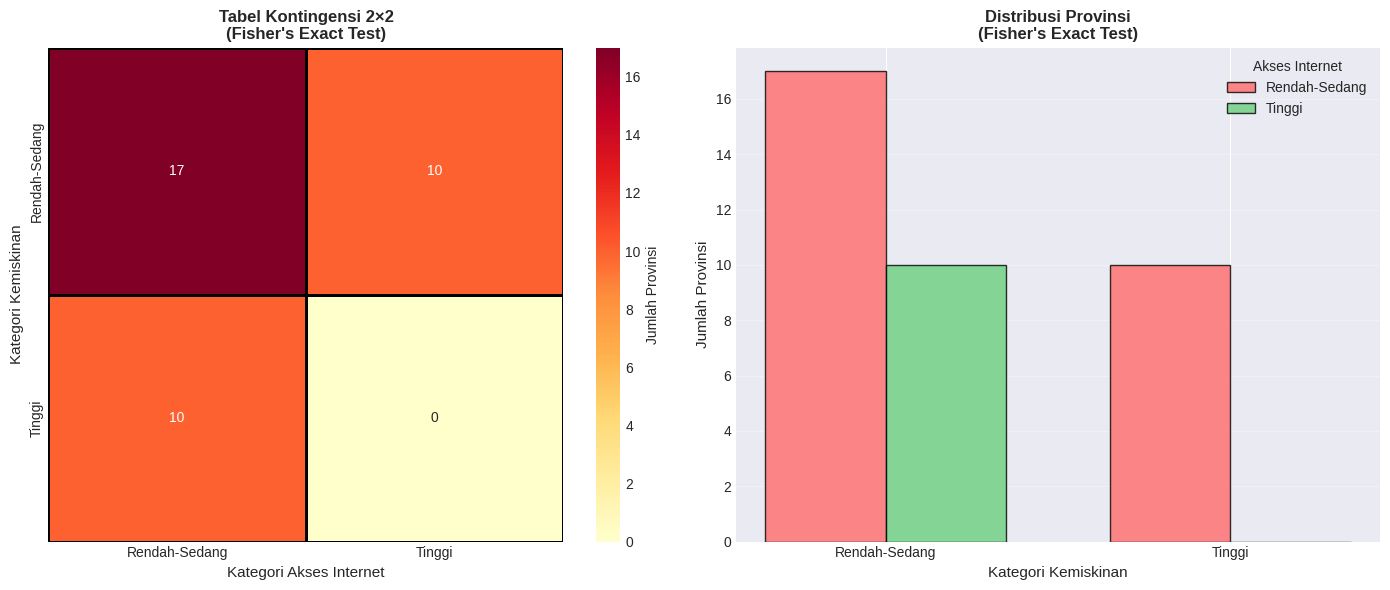



6.4 Visualisasi Chi-Square
--------------------------------------------------------------------------------


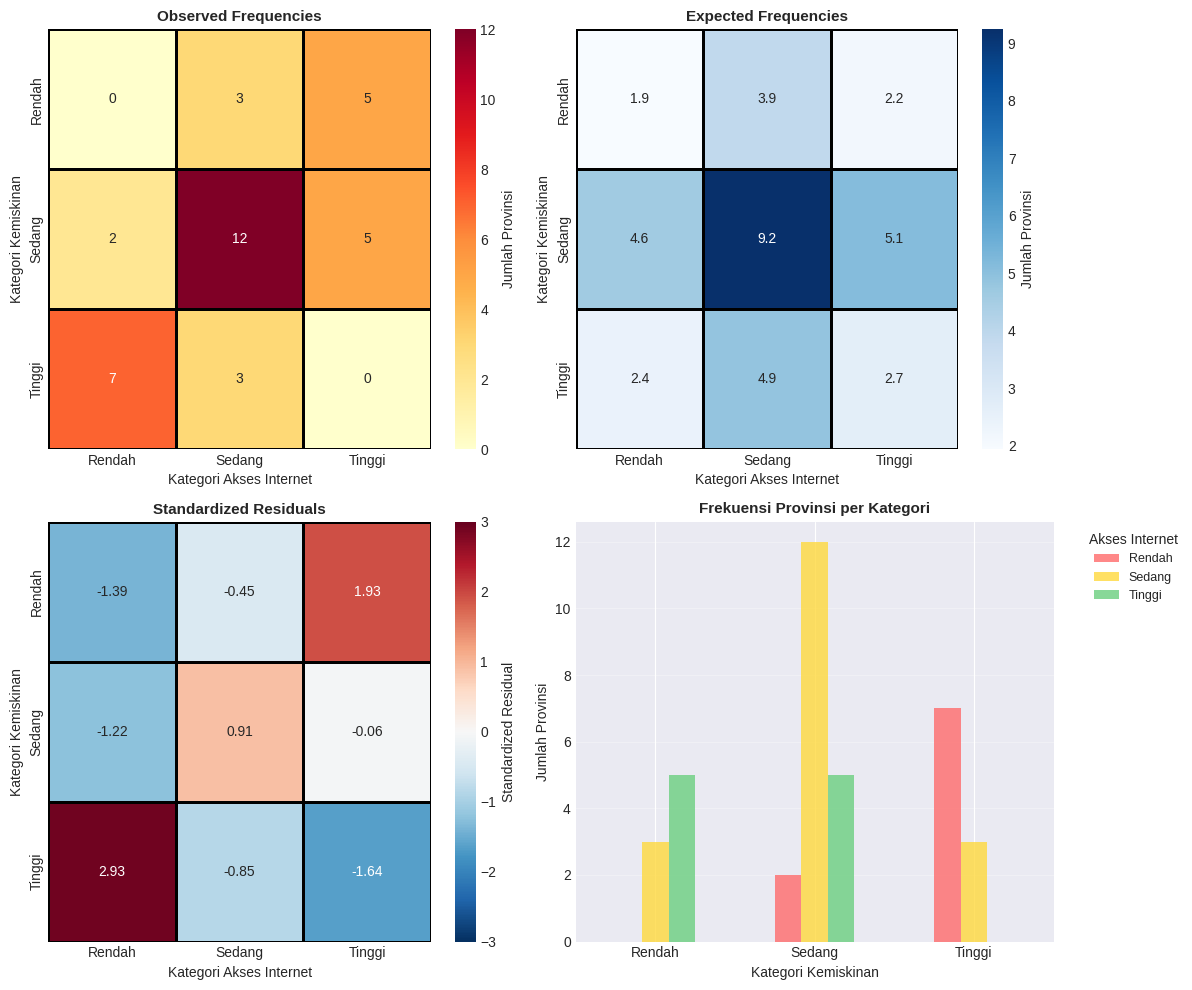

In [ ]:
# ================================================================================
# BAGIAN 6: UJI CHI-SQUARE
# ================================================================================

print("="*80)
print("BAGIAN 6: UJI CHI-SQUARE")
print("="*80)

# --------------------------------------------------------------------------------
# 6.1 Chi-Square Test of Independence
# --------------------------------------------------------------------------------

print("\n6.1 Chi-Square Test of Independence")
print("-"*80)

# Crosstabulation
crosstab = pd.crosstab(df['Kategori_Kemiskinan'], df['Kategori_Internet'])

print("\nTabel Kontingensi (Frekuensi Observasi):")
print(crosstab)

# Total Marginal
print("\nTotal Marginal:")
print(f"Total per Kategori Kemiskinan:")
print(crosstab.sum(axis=1))
print(f"\nTotal per Kategori Akses Internet:")
print(crosstab.sum(axis=0))
print(f"\nTotal Keseluruhan: {crosstab.sum().sum()} provinsi")

# Persentase per baris
crosstab_pct = pd.crosstab(df['Kategori_Kemiskinan'], df['Kategori_Internet'], normalize='index') * 100

print("\nTabel Kontingensi (Persentase per Baris):")
print(crosstab_pct.round(2))

# Chi-square test
chi2, p_value_chi, dof_chi, expected = stats.chi2_contingency(crosstab)

print(f"\nHipotesis:")
print(f"  H₀: Tidak ada hubungan antara kategori kemiskinan dan kategori akses internet")
print(f"  H₁: Ada hubungan antara kategori kemiskinan dan kategori akses internet")

print(f"\nHasil Uji Chi-Square:")
print(f"  χ² statistic: {chi2:.4f}")
print(f"  Degrees of Freedom: {dof_chi}")
print(f"  p-value: {p_value_chi:.6f}")
print(f"  Critical value (α=0.05): {stats.chi2.ppf(0.95, dof_chi):.4f}")

if p_value_chi < 0.05:
    print(f"\nKeputusan: TOLAK H₀")
    print(f"Kesimpulan: Terdapat hubungan SIGNIFIKAN antara kategori kemiskinan dan")
    print(f"            kategori akses internet (p < 0.05)")
else:
    print(f"\nKeputusan: GAGAL TOLAK H₀")
    print(f"Kesimpulan: Tidak terdapat hubungan signifikan (p ≥ 0.05)")

# --------------------------------------------------------------------------------
# 6.2 Effect Size (Cramer's V)
# --------------------------------------------------------------------------------

print("\n\n6.2 Effect Size (Cramer's V)")
print("-"*80)

n_total = crosstab.sum().sum()
min_dim = min(crosstab.shape[0], crosstab.shape[1]) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))

print(f"\nCramer's V: {cramers_v:.4f}")
print(f"Degrees of Freedom (df): {min_dim}")

# THRESHOLD DISESUAIKAN DENGAN DF
if min_dim == 1:  # Tabel 2x2
    print("\nSkala interpretasi (untuk tabel 2×2, df=1):")
    print("  0.00 - 0.10 : Sangat Lemah")
    print("  0.10 - 0.30 : Lemah")
    print("  0.30 - 0.50 : Sedang")
    print("  > 0.50      : Kuat")

    if cramers_v < 0.10:
        strength_cramers = "Sangat Lemah"
    elif cramers_v < 0.30:
        strength_cramers = "Lemah"
    elif cramers_v < 0.50:
        strength_cramers = "Sedang"
    else:
        strength_cramers = "Kuat"

elif min_dim == 2:  # Tabel 3x3
    print("\nSkala interpretasi (untuk tabel 3×3, df=2):")
    print("  0.00 - 0.07 : Sangat Lemah")
    print("  0.07 - 0.21 : Lemah")
    print("  0.21 - 0.35 : Sedang")
    print("  > 0.35      : Kuat/Sangat Kuat")

    if cramers_v < 0.07:
        strength_cramers = "Sangat Lemah"
    elif cramers_v < 0.21:
        strength_cramers = "Lemah"
    elif cramers_v < 0.35:
        strength_cramers = "Sedang"
    else:
        strength_cramers = "Sangat Kuat"

else:  # Tabel lebih besar
    print(f"\nSkala interpretasi (untuk df={min_dim}):")
    print("  0.00 - 0.06 : Sangat Lemah")
    print("  0.06 - 0.17 : Lemah")
    print("  0.17 - 0.29 : Sedang")
    print("  > 0.29      : Kuat/Sangat Kuat")

    if cramers_v < 0.06:
        strength_cramers = "Sangat Lemah"
    elif cramers_v < 0.17:
        strength_cramers = "Lemah"
    elif cramers_v < 0.29:
        strength_cramers = "Sedang"
    else:
        strength_cramers = "Sangat Kuat"

print(f"\nInterpretasi: Kekuatan hubungan {strength_cramers}")
print(f"(Berdasarkan penyesuaian untuk df={min_dim})")

# --------------------------------------------------------------------------------
# 6.3 Expected Frequencies dan Standardized Residuals
# --------------------------------------------------------------------------------

print("\n\n6.3 Expected Frequencies dan Standardized Residuals")
print("-"*80)

expected_df = pd.DataFrame(expected,
                          index=crosstab.index,
                          columns=crosstab.columns)

print(f"\nExpected Frequencies (Frekuensi Harapan):")
print(expected_df.round(2))

print("\nCatatan:")
print("  Semua sel sebaiknya memiliki frekuensi harapan ≥ 5 agar uji chi-square optimal.")

# CEK ASUMSI EXPECTED FREQUENCY
min_expected = expected_df.min().min()
cells_below_5 = np.sum(expected < 5)
total_cells = expected.size
pct_below_5 = cells_below_5 / total_cells * 100

print(f"\nCek Asumsi:")
print(f"  Frekuensi harapan terkecil: {min_expected:.2f}")
print(f"  Sel dengan frekuensi harapan < 5: {cells_below_5}/{total_cells} ({pct_below_5:.1f}%)")

if min_expected >= 5:
    print(f"  Status: Asumsi TERPENUHI dengan baik (semua sel ≥ 5)")
    print(f"  → Hasil chi-square dapat dipercaya.")
    needs_fisher = False
else:
    print(f"  Status: Asumsi TIDAK SEPENUHNYA terpenuhi")
    print(f"  → Solusi: Gunakan Fisher's Exact Test (lihat Bagian 6.3.1)")
    needs_fisher = True

# Standardized Residuals
print(f"\nStandardized Residuals:")
residuals = (crosstab - expected_df) / np.sqrt(expected_df)
print(residuals.round(3))

print("\nInterpretasi:")
print("  Nilai > 2 atau < -2: Kontribusi signifikan terhadap chi-square")
print("  Nilai positif: Frekuensi observasi > ekspektasi")
print("  Nilai negatif: Frekuensi observasi < ekspektasi")

# Kontribusi setiap sel
contributions = ((crosstab - expected_df)**2) / expected_df
contributions_pct = (contributions / chi2) * 100

print(f"\nKontribusi Setiap Sel terhadap χ² (%):")
print(contributions_pct.round(2))

# TAMBAHAN: RANKING SEL BERDASARKAN KONTRIBUSI (dari Rumusan Masalah 2)

print(f"\n" + "="*80)
print("RANKING SEL BERDASARKAN KONTRIBUSI TERHADAP χ²")
print("="*80)

# Buat list semua sel dengan kontribusinya
contributions_list = []
for i in crosstab.index:
    for j in crosstab.columns:
        contributions_list.append({
            'Kemiskinan': i,
            'Internet': j,
            'Observasi': crosstab.loc[i, j],
            'Ekspektasi': expected_df.loc[i, j],
            'Residual': residuals.loc[i, j],
            'Kontribusi': contributions.loc[i, j],
            'Kontribusi_Pct': contributions_pct.loc[i, j]
        })

# Sort berdasarkan kontribusi (dari terbesar ke terkecil)
contributions_sorted = sorted(contributions_list, key=lambda x: x['Kontribusi'], reverse=True)

print(f"\nTabel Ranking Lengkap:")
print("-"*100)
print(f"{'Rank':>4} | {'Kemiskinan':>15} | {'Internet':>15} | {'Obs':>4} | {'Exp':>6} | {'Residual':>9} | {'Kontribusi':>11} | {'% χ²':>7}")
print("-"*100)

for idx, cell in enumerate(contributions_sorted, 1):
    print(f"{idx:>4} | {cell['Kemiskinan']:>15} | {cell['Internet']:>15} | "
          f"{cell['Observasi']:>4} | {cell['Ekspektasi']:>6.2f} | {cell['Residual']:>9.3f} | "
          f"{cell['Kontribusi']:>11.4f} | {cell['Kontribusi_Pct']:>7.2f}%")

print("-"*100)

# JAWABAN SPESIFIK untuk sel dengan kontribusi terbesar
print(f"\n" + "="*80)
print("KATEGORI DENGAN KONTRIBUSI TERBESAR")
print("="*80)

top_cell = contributions_sorted[0]

print(f"\nSel dengan kontribusi terbesar terhadap nilai χ²:")
print(f"  Kategori: [{top_cell['Kemiskinan']} × {top_cell['Internet']}]")
print(f"  Kontribusi: {top_cell['Kontribusi']:.4f} ({top_cell['Kontribusi_Pct']:.2f}% dari total χ²)")

print(f"\nDetail Sel:")
print(f"  Frekuensi Observasi: {top_cell['Observasi']} provinsi")
print(f"  Frekuensi Ekspektasi: {top_cell['Ekspektasi']:.2f} provinsi")
print(f"  Selisih: {top_cell['Observasi'] - top_cell['Ekspektasi']:.2f} provinsi")
print(f"  Standardized Residual: {top_cell['Residual']:.3f}")

print(f"\nInterpretasi:")
if top_cell['Residual'] > 0:
    print(f"  Provinsi dengan kemiskinan {top_cell['Kemiskinan']} memiliki frekuensi")
    print(f"  akses internet {top_cell['Internet']} yang LEBIH BANYAK dari yang diharapkan.")
    print(f"  Observasi: {top_cell['Observasi']} provinsi vs Ekspektasi: {top_cell['Ekspektasi']:.1f} provinsi")
    print(f"  (selisih: +{top_cell['Observasi'] - top_cell['Ekspektasi']:.1f} provinsi)")
else:
    print(f"  Provinsi dengan kemiskinan {top_cell['Kemiskinan']} memiliki frekuensi")
    print(f"  akses internet {top_cell['Internet']} yang LEBIH SEDIKIT dari yang diharapkan.")
    print(f"  Observasi: {top_cell['Observasi']} provinsi vs Ekspektasi: {top_cell['Ekspektasi']:.1f} provinsi")
    print(f"  (selisih: {top_cell['Observasi'] - top_cell['Ekspektasi']:.1f} provinsi)")

print(f"\nKontribusi terhadap signifikansi:")
print(f"  Sel ini berkontribusi {top_cell['Kontribusi_Pct']:.2f}% terhadap total nilai χ².")
print(f"  Ini adalah kontribusi TERBESAR di antara semua {len(contributions_sorted)} sel,")
print(f"  sehingga sel ini paling menentukan signifikansi hubungan antara")
print(f"  kategori kemiskinan dan kategori akses internet.")

# Top 3 sel dengan kontribusi terbesar
print(f"\n" + "-"*80)
print("TOP 3 SEL DENGAN KONTRIBUSI TERBESAR")
print("-"*80)

for idx in range(min(3, len(contributions_sorted))):
    cell = contributions_sorted[idx]
    print(f"\nRank {idx + 1}: [{cell['Kemiskinan']} × {cell['Internet']}]")
    print(f"  Kontribusi: {cell['Kontribusi_Pct']:.2f}% dari total χ²")
    print(f"  Observasi: {cell['Observasi']} | Ekspektasi: {cell['Ekspektasi']:.1f}")
    print(f"  Residual: {cell['Residual']:.3f} → {'LEBIH BANYAK' if cell['Residual'] > 0 else 'LEBIH SEDIKIT'}")

# AKHIR TAMBAHAN

# Interpretasi detail per sel (yang signifikan)
print(f"\n" + "="*80)
print("INTERPRETASI DETAIL SEL DENGAN RESIDUAL SIGNIFIKAN (|residual| > 2)")
print("="*80)

sig_cells_found = False
for i in residuals.index:
    for j in residuals.columns:
        res = residuals.loc[i, j]
        obs = crosstab.loc[i, j]
        exp = expected_df.loc[i, j]
        contrib = contributions_pct.loc[i, j]

        if abs(res) > 2:
            sig_cells_found = True
            direction = "LEBIH BANYAK" if res > 0 else "LEBIH SEDIKIT"
            print(f"\n  [{i} × {j}]:")
            print(f"    Observasi: {obs} | Ekspektasi: {exp:.1f}")
            print(f"    Residual: {res:.3f} → {direction} dari yang diharapkan")
            print(f"    Kontribusi: {contrib:.2f}%")

            # Interpretasi substantif
            if res > 2:
                print(f"    → Terdapat OVER-REPRESENTATION: Provinsi dengan kemiskinan {i}")
                print(f"       memiliki kecenderungan kuat untuk memiliki akses internet {j}.")
            elif res < -2:
                print(f"    → Terdapat UNDER-REPRESENTATION: Provinsi dengan kemiskinan {i}")
                print(f"       memiliki kecenderungan rendah untuk memiliki akses internet {j}.")

if not sig_cells_found:
    print("\n  Tidak ada sel dengan residual signifikan (|residual| > 2)")
    print("  Ini mengindikasikan bahwa meskipun chi-square mungkin signifikan,")
    print("  tidak ada sel individual yang secara ekstrem menyimpang dari ekspektasi.")

# --------------------------------------------------------------------------------
# 6.3.1 Fisher's Exact Test
# --------------------------------------------------------------------------------

if needs_fisher:
    print("\n\n6.3.1 Fisher's Exact Test")
    print("-"*80)

    print("\nRasional Pemilihan Metode:")
    print(f"  Karena {pct_below_5:.1f}% sel memiliki frekuensi harapan < 5,")
    print("  Fisher's Exact Test dipilih sebagai metode yang lebih tepat.")
    print("  Metode ini TIDAK memerlukan asumsi expected frequency ≥ 5,")
    print("  sehingga lebih akurat untuk data dengan frekuensi kecil.")

    print("\nPersiapan Data:")
    print("  Kategori digabung menjadi 2×2 agar analisis lebih robust:")
    print("  • Kemiskinan : 'Rendah+Sedang' vs 'Tinggi'")
    print("  • Internet   : 'Rendah+Sedang' vs 'Tinggi'")

    # Buat kategori biner
    df['Kemiskinan_Binary'] = df['Kategori_Kemiskinan'].apply(
        lambda x: 'Tinggi' if x == 'Tinggi' else 'Rendah-Sedang'
    )
    df['Internet_Binary'] = df['Kategori_Internet'].apply(
        lambda x: 'Tinggi' if x == 'Tinggi' else 'Rendah-Sedang'
    )

    # Crosstab 2×2
    crosstab_2x2 = pd.crosstab(df['Kemiskinan_Binary'], df['Internet_Binary'])

    print("\nTabel Kontingensi 2×2:")
    print(crosstab_2x2)

    print("\nStruktur tabel untuk Fisher's Exact Test:")
    print(f"  Format: [[a, b], [c, d]]")
    table_array = crosstab_2x2.values
    print(f"  Nilai: {table_array.tolist()}")

    # Fisher's Exact Test
    from scipy.stats import fisher_exact

    oddsratio, p_fisher = fisher_exact(crosstab_2x2, alternative='two-sided')

    print("\nHasil Fisher's Exact Test:")
    if oddsratio == float('inf'):
        print(f"  Odds Ratio: ∞ (tak hingga)")
    elif oddsratio == 0:
        print(f"  Odds Ratio: 0 (nol)")
    else:
        print(f"  Odds Ratio: {oddsratio:.4f}")
    print(f"  p-value (two-tailed): {p_fisher:.6f}")
    print(f"  Tingkat signifikansi (α): 0.05")

    print("\nHipotesis:")
    print("  H₀: Tidak ada hubungan antara kategori kemiskinan dan akses internet")
    print("  H₁: Ada hubungan antara kategori kemiskinan dan akses internet")

    print("\nKeputusan:")
    if p_fisher < 0.05:
        print(f"  p-value ({p_fisher:.6f}) < 0.05 → TOLAK H₀")
        print("  Kesimpulan: Terdapat hubungan yang SIGNIFIKAN.")
    else:
        print(f"  p-value ({p_fisher:.6f}) ≥ 0.05 → GAGAL TOLAK H₀")
        print("  Kesimpulan: Tidak terdapat hubungan yang signifikan.")

    print("\nInterpretasi Odds Ratio:")

    if oddsratio == float('inf'):
        print("  Odds Ratio = ∞ (tak hingga)")
        print("  → Terdapat sel dengan nilai 0 yang membuat perhitungan odds ratio tak hingga.")
        print("  → Ini mengindikasikan pola asosiasi yang sangat kuat:")
        print("     Salah satu kombinasi kategori TIDAK DITEMUKAN sama sekali dalam data.")

    elif oddsratio == 0:
        print("  Odds Ratio = 0 (nol)")
        print("  → Terdapat sel dengan nilai 0 yang membuat perhitungan odds ratio = 0.")
        print("\n  Interpretasi substantif:")

        # Cek sel mana yang 0
        if crosstab_2x2.loc['Tinggi', 'Tinggi'] == 0:
            print("  → TIDAK ADA SATUPUN provinsi dengan kemiskinan TINGGI yang memiliki")
            print("     akses internet TINGGI (sel bernilai 0).")
            print("  → Ini mengindikasikan kesenjangan digital yang sangat kuat:")
            print("     Provinsi miskin cenderung TIDAK memiliki akses internet tinggi.")
        else:
            # Cari sel lain yang 0
            for idx_row in crosstab_2x2.index:
                for idx_col in crosstab_2x2.columns:
                    if crosstab_2x2.loc[idx_row, idx_col] == 0:
                        print(f"  → Tidak ada provinsi dengan kemiskinan {idx_row} dan")
                        print(f"     akses internet {idx_col} (sel bernilai 0).")

    else:
        print(f"  Odds Ratio = {oddsratio:.2f}")
        if oddsratio > 1:
            print(f"  → Provinsi dengan kemiskinan Rendah-Sedang memiliki peluang")
            print(f"     {oddsratio:.2f}× lebih tinggi untuk memiliki akses internet Tinggi")
            print(f"     dibanding provinsi dengan kemiskinan Tinggi.")
        elif oddsratio < 1:
            inv_or = 1 / oddsratio
            print(f"  → Provinsi dengan kemiskinan Tinggi memiliki peluang")
            print(f"     {inv_or:.2f}× lebih RENDAH untuk memiliki akses internet Tinggi")
            print(f"     dibanding provinsi dengan kemiskinan Rendah-Sedang.")

    # Visualisasi tabel 2x2
    print("\nVisualisasi Tabel 2×2:")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Heatmap
    sns.heatmap(
        crosstab_2x2,
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        cbar_kws={'label': 'Jumlah Provinsi'},
        ax=axes[0],
        linewidths=1,
        linecolor='black'
    )
    axes[0].set_title(f'Tabel Kontingensi 2×2\n(Fisher\'s Exact Test)',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Kategori Akses Internet', fontsize=11)
    axes[0].set_ylabel('Kategori Kemiskinan', fontsize=11)

    # Plot 2: Grouped Bar Chart
    x = np.arange(len(crosstab_2x2.index))
    width = 0.35
    colors = ['#ff6b6b', '#6bcf7f']

    for i, col in enumerate(crosstab_2x2.columns):
        axes[1].bar(
            x + i * width,
            crosstab_2x2[col],
            width,
            label=col,
            color=colors[i],
            edgecolor='black',
            alpha=0.8
        )

    axes[1].set_xlabel('Kategori Kemiskinan', fontsize=11)
    axes[1].set_ylabel('Jumlah Provinsi', fontsize=11)
    axes[1].set_title(f'Distribusi Provinsi\n(Fisher\'s Exact Test)',
                      fontsize=12, fontweight='bold')
    axes[1].set_xticks(x + width / 2)
    axes[1].set_xticklabels(crosstab_2x2.index)
    axes[1].legend(title='Akses Internet', fontsize=10)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Simpan hasil untuk ringkasan akhir
    chi2_final = None
    p_value_final = p_fisher
    dof_final = None
    crosstab_final = crosstab_2x2
    method_label = "Fisher's Exact Test (2×2)"
    odds_ratio_final = oddsratio

else:
    # Asumsi chi-square sudah oke dari awal
    chi2_final = chi2
    p_value_final = p_value_chi
    dof_final = dof_chi
    crosstab_final = crosstab
    method_label = "Chi-Square (3×3)"
    odds_ratio_final = None

# --------------------------------------------------------------------------------
# 6.4 Visualisasi Chi-Square
# --------------------------------------------------------------------------------

print("\n\n6.4 Visualisasi Chi-Square")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Heatmap - Observed frequencies
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Jumlah Provinsi'}, ax=axes[0, 0],
            linewidths=1, linecolor='black')
axes[0, 0].set_title('Observed Frequencies', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Kategori Akses Internet', fontsize=10)
axes[0, 0].set_ylabel('Kategori Kemiskinan', fontsize=10)

# 2. Heatmap - Expected frequencies
sns.heatmap(expected_df, annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': 'Jumlah Provinsi'}, ax=axes[0, 1],
            linewidths=1, linecolor='black')
axes[0, 1].set_title('Expected Frequencies', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Kategori Akses Internet', fontsize=10)
axes[0, 1].set_ylabel('Kategori Kemiskinan', fontsize=10)

# 3. Heatmap - Standardized Residuals
sns.heatmap(residuals, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Standardized Residual'}, ax=axes[1, 0],
            linewidths=1, linecolor='black', vmin=-3, vmax=3)
axes[1, 0].set_title('Standardized Residuals', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Kategori Akses Internet', fontsize=10)
axes[1, 0].set_ylabel('Kategori Kemiskinan', fontsize=10)

# 4. Grouped Bar Chart
crosstab.plot(kind='bar', ax=axes[1, 1], color=['#ff6b6b', '#ffd93d', '#6bcf7f'], alpha=0.8)
axes[1, 1].set_title('Frekuensi Provinsi per Kategori', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Kategori Kemiskinan', fontsize=10)
axes[1, 1].set_ylabel('Jumlah Provinsi', fontsize=10)
axes[1, 1].legend(title='Akses Internet', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

6.5 Post-Hoc Analysis (Pairwise Comparison)
--------------------------------------------------------------------------------

Karena chi-square signifikan, dilakukan pairwise comparison
untuk mengetahui kategori mana yang paling berkontribusi

Bonferroni-corrected α: 0.005556

(A) Perbandingan Antar Kategori Kemiskinan:
    Rendah vs Sedang:
      χ² = 3.4993, p = 0.173831 → Tidak signifikan
    Rendah vs Tinggi:
      χ² = 11.9250, p = 0.002573 → SIGNIFIKAN
    Sedang vs Tinggi:
      χ² = 11.4915, p = 0.003196 → SIGNIFIKAN

(B) Perbandingan Antar Kategori Akses Internet:
    Rendah vs Sedang:
      χ² = 9.8357, p = 0.007315 → Tidak signifikan
    Rendah vs Tinggi:
      χ² = 13.2698, p = 0.001314 → SIGNIFIKAN
    Sedang vs Tinggi:
      χ² = 4.4608, p = 0.107486 → Tidak signifikan


6.6 Goodness of Fit Tests
--------------------------------------------------------------------------------

(1) Uji Kecocokan Distribusi Akses Internet
    H₀: Distribusi akses internet merata (33.3% : 33

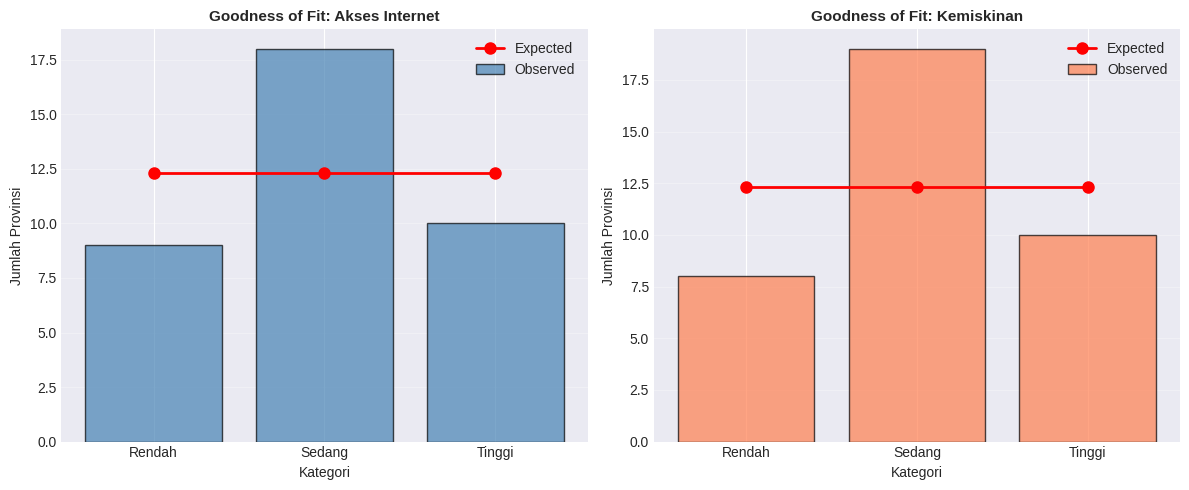



6.7 Perbandingan Cramer's V vs Regresi Linear

Metode ini membandingkan kekuatan hubungan dari dua perspektif:
  1. KATEGORIK: Cramer's V (berdasarkan chi-square)
  2. NUMERIK: Korelasi Pearson & R² (berdasarkan regresi linear)

1. RINGKASAN HASIL
--------------------------------------------------------------------------------

A. Ukuran Asosiasi Kategorik (Chi-Square):
   Metode: Cramer's V
   Nilai: 0.5222
   Kekuatan: Sangat Kuat
   p-value (χ²): 0.000460
   Signifikan: YA

B. Ukuran Asosiasi Numerik (Regresi Linear):
   Metode: Korelasi Pearson & Koefisien Determinasi
   Korelasi Pearson (r): -0.8215
   Koefisien Determinasi (R²): 0.6748
   Kekuatan: SANGAT KUAT
   Arah: NEGATIF
   p-value: 0.000000
   Signifikan: YA

2. INTERPRETASI KEKUATAN HUBUNGAN
--------------------------------------------------------------------------------

Dari perspektif DATA KATEGORIK:
  Hubungan antara kategori kemiskinan dan kategori akses internet
  tergolong SANGAT KUAT (Cramer's V = 0.5222).

Dari

In [ ]:
# --------------------------------------------------------------------------------
# 6.5 Post-Hoc Analysis (Pairwise Comparison)
# --------------------------------------------------------------------------------

print("6.5 Post-Hoc Analysis (Pairwise Comparison)")
print("-"*80)

if p_value_chi < 0.05:
    print("\nKarena chi-square signifikan, dilakukan pairwise comparison")
    print("untuk mengetahui kategori mana yang paling berkontribusi")

    from itertools import combinations

    # Bonferroni correction
    n_comparisons = len(list(combinations(crosstab.index, 2))) * len(list(combinations(crosstab.columns, 2)))
    alpha_corrected = 0.05 / n_comparisons if n_comparisons > 0 else 0.05

    print(f"\nBonferroni-corrected α: {alpha_corrected:.6f}")

    # Comparison antar kategori kemiskinan
    print(f"\n(A) Perbandingan Antar Kategori Kemiskinan:")
    for cat1, cat2 in combinations(crosstab.index, 2):
        subset = crosstab.loc[[cat1, cat2], :]
        chi2_pair, p_pair, _, _ = stats.chi2_contingency(subset)

        sig = "SIGNIFIKAN" if p_pair < alpha_corrected else "Tidak signifikan"
        print(f"    {cat1} vs {cat2}:")
        print(f"      χ² = {chi2_pair:.4f}, p = {p_pair:.6f} → {sig}")

    # Comparison antar kategori internet
    print(f"\n(B) Perbandingan Antar Kategori Akses Internet:")
    for cat1, cat2 in combinations(crosstab.columns, 2):
        subset = crosstab.loc[:, [cat1, cat2]]
        chi2_pair, p_pair, _, _ = stats.chi2_contingency(subset)

        sig = "SIGNIFIKAN" if p_pair < alpha_corrected else "Tidak signifikan"
        print(f"    {cat1} vs {cat2}:")
        print(f"      χ² = {chi2_pair:.4f}, p = {p_pair:.6f} → {sig}")

else:
    print("\nChi-square tidak signifikan, post-hoc analysis tidak dilakukan")

# --------------------------------------------------------------------------------
# 6.6 Goodness of Fit Tests
# --------------------------------------------------------------------------------

print("\n\n6.6 Goodness of Fit Tests")
print("-"*80)

# Test 1: Distribusi Akses Internet
observed_internet = df['Kategori_Internet'].value_counts().sort_index()
n_internet = len(df)
expected_internet = np.array([n_internet/3, n_internet/3, n_internet/3])

chi2_gof_internet = np.sum((observed_internet.values - expected_internet)**2 / expected_internet)
dof_gof = len(observed_internet) - 1
p_gof_internet = 1 - stats.chi2.cdf(chi2_gof_internet, dof_gof)

print(f"\n(1) Uji Kecocokan Distribusi Akses Internet")
print(f"    H₀: Distribusi akses internet merata (33.3% : 33.3% : 33.3%)")
print(f"    H₁: Distribusi akses internet tidak merata")
print(f"\n    Observed: Rendah={observed_internet['Rendah']}, Sedang={observed_internet['Sedang']}, Tinggi={observed_internet['Tinggi']}")
print(f"    Expected: Rendah={expected_internet[0]:.1f}, Sedang={expected_internet[1]:.1f}, Tinggi={expected_internet[2]:.1f}")
print(f"\n    χ²: {chi2_gof_internet:.4f}")
print(f"    df: {dof_gof}")
print(f"    p-value: {p_gof_internet:.6f}")
print(f"    Critical value (α=0.05): {stats.chi2.ppf(0.95, dof_gof):.4f}")

if p_gof_internet < 0.05:
    print(f"\n    Keputusan: TOLAK H₀")
    print(f"    Kesimpulan: Distribusi akses internet TIDAK merata di Indonesia (p < 0.05)")
else:
    print(f"\n    Keputusan: GAGAL TOLAK H₀")
    print(f"    Kesimpulan: Distribusi akses internet relatif merata (p ≥ 0.05)")

# Test 2: Distribusi Kemiskinan
observed_poverty = df['Kategori_Kemiskinan'].value_counts().sort_index()
n_poverty = len(df)
expected_poverty = np.array([n_poverty/3, n_poverty/3, n_poverty/3])

chi2_gof_poverty = np.sum((observed_poverty.values - expected_poverty)**2 / expected_poverty)
p_gof_poverty = 1 - stats.chi2.cdf(chi2_gof_poverty, dof_gof)

print(f"\n(2) Uji Kecocokan Distribusi Kemiskinan")
print(f"    H₀: Distribusi kemiskinan merata (33.3% : 33.3% : 33.3%)")
print(f"    H₁: Distribusi kemiskinan tidak merata")
print(f"\n    Observed: Rendah={observed_poverty['Rendah']}, Sedang={observed_poverty['Sedang']}, Tinggi={observed_poverty['Tinggi']}")
print(f"    Expected: Rendah={expected_poverty[0]:.1f}, Sedang={expected_poverty[1]:.1f}, Tinggi={expected_poverty[2]:.1f}")
print(f"\n    χ²: {chi2_gof_poverty:.4f}")
print(f"    df: {dof_gof}")
print(f"    p-value: {p_gof_poverty:.6f}")
print(f"    Critical value (α=0.05): {stats.chi2.ppf(0.95, dof_gof):.4f}")

if p_gof_poverty < 0.05:
    print(f"\n    Keputusan: TOLAK H₀")
    print(f"    Kesimpulan: Distribusi kemiskinan TIDAK merata di Indonesia (p < 0.05)")
else:
    print(f"\n    Keputusan: GAGAL TOLAK H₀")
    print(f"    Kesimpulan: Distribusi kemiskinan relatif merata (p ≥ 0.05)")

# Visualisasi GoF
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# GoF - Internet
x = np.arange(len(observed_internet))
axes[0].bar(x, observed_internet.values, alpha=0.7, color='steelblue',
            edgecolor='black', label='Observed')
axes[0].plot(x, expected_internet, 'ro-', linewidth=2, markersize=8, label='Expected')
axes[0].set_xticks(x)
axes[0].set_xticklabels(observed_internet.index)
axes[0].set_title('Goodness of Fit: Akses Internet', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Kategori', fontsize=10)
axes[0].set_ylabel('Jumlah Provinsi', fontsize=10)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# GoF - Kemiskinan
x = np.arange(len(observed_poverty))
axes[1].bar(x, observed_poverty.values, alpha=0.7, color='coral',
            edgecolor='black', label='Observed')
axes[1].plot(x, expected_poverty, 'ro-', linewidth=2, markersize=8, label='Expected')
axes[1].set_xticks(x)
axes[1].set_xticklabels(observed_poverty.index)
axes[1].set_title('Goodness of Fit: Kemiskinan', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Kategori', fontsize=10)
axes[1].set_ylabel('Jumlah Provinsi', fontsize=10)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------
# 6.7 Perbandingan Cramer's V vs Regresi Linear
# --------------------------------------------------------------------------------

print("\n\n6.7 Perbandingan Cramer's V vs Regresi Linear")
print("="*80)

print("\nMetode ini membandingkan kekuatan hubungan dari dua perspektif:")
print("  1. KATEGORIK: Cramer's V (berdasarkan chi-square)")
print("  2. NUMERIK: Korelasi Pearson & R² (berdasarkan regresi linear)")

# Ambil hasil dari Bagian 5 (pastikan variabel sudah ada)
try:
    r_pearson_value = r_pearson
    r2_value = r2
    corr_strength_value = corr_strength
except NameError:
    # Hitung ulang jika variabel tidak ada
    r_pearson_value, _ = stats.pearsonr(df[kemiskinan_col], df[internet_col])
    r2_value = r_pearson_value ** 2

    abs_r = abs(r_pearson_value)
    if abs_r < 0.10:
        corr_strength_value = "SANGAT LEMAH"
    elif abs_r < 0.30:
        corr_strength_value = "LEMAH"
    elif abs_r < 0.50:
        corr_strength_value = "SEDANG"
    elif abs_r < 0.70:
        corr_strength_value = "KUAT"
    else:
        corr_strength_value = "SANGAT KUAT"

print("\n1. RINGKASAN HASIL")
print("-"*80)

print(f"\nA. Ukuran Asosiasi Kategorik (Chi-Square):")
print(f"   Metode: Cramer's V")
print(f"   Nilai: {cramers_v:.4f}")
print(f"   Kekuatan: {strength_cramers}")
print(f"   p-value (χ²): {p_value_chi:.6f}")
print(f"   Signifikan: {'YA' if p_value_chi < 0.05 else 'TIDAK'}")

print(f"\nB. Ukuran Asosiasi Numerik (Regresi Linear):")
print(f"   Metode: Korelasi Pearson & Koefisien Determinasi")
print(f"   Korelasi Pearson (r): {r_pearson_value:.4f}")
print(f"   Koefisien Determinasi (R²): {r2_value:.4f}")
print(f"   Kekuatan: {corr_strength_value}")
print(f"   Arah: {'NEGATIF' if r_pearson_value < 0 else 'POSITIF'}")
print(f"   p-value: {p_pearson:.6f}")
print(f"   Signifikan: {'YA' if p_pearson < 0.05 else 'TIDAK'}")

print("\n2. INTERPRETASI KEKUATAN HUBUNGAN")
print("-"*80)

print(f"\nDari perspektif DATA KATEGORIK:")
print(f"  Hubungan antara kategori kemiskinan dan kategori akses internet")
print(f"  tergolong {strength_cramers.upper()} (Cramer's V = {cramers_v:.4f}).")

print(f"\nDari perspektif DATA NUMERIK:")
print(f"  Hubungan linear antara persentase kemiskinan dan persentase akses")
print(f"  internet tergolong {corr_strength_value} (r = {r_pearson_value:.4f}, R² = {r2_value:.4f}).")

# Consistency check
cramers_moderate = cramers_v >= 0.21 if min_dim == 2 else cramers_v >= 0.30
pearson_moderate = abs(r_pearson_value) >= 0.30

if (cramers_moderate and pearson_moderate) or (not cramers_moderate and not pearson_moderate):
    consistency = "KONSISTEN"
    print(f"\n  Kedua metode menunjukkan hasil yang {consistency}.")
    print(f"  Baik pendekatan kategorik maupun numerik mengindikasikan")
    print(f"  kekuatan hubungan yang {'KUAT/SEDANG' if cramers_moderate else 'LEMAH'}.")
else:
    consistency = "BERBEDA"
    print(f"\n  Terdapat PERBEDAAN interpretasi antara kedua metode:")
    print(f"  - Cramer's V ({cramers_v:.4f}): {strength_cramers}")
    print(f"  - Pearson r ({r_pearson_value:.4f}): {corr_strength_value}")
    print(f"\n  Perbedaan ini dapat terjadi karena:")
    print(f"  • Cramer's V mengukur asosiasi kategorik (kehilangan informasi detail)")
    print(f"  • Korelasi Pearson mengukur hubungan linear numerik (lebih sensitif)")
    print(f"  • Kategorisasi data dapat mengurangi/meningkatkan deteksi hubungan")

print("\n3. KESIMPULAN AKHIR")
print("="*80)

if p_value_chi < 0.05 and p_pearson < 0.05:
    print(f"\n✓ Hubungan antara tingkat kemiskinan dan akses internet antarprovinsi")
    print(f"  di Indonesia tahun 2024 adalah SIGNIFIKAN secara statistik")
    print(f"  (p-value < 0.05 untuk kedua metode).")

    print(f"\n✓ Kekuatan hubungan:")
    print(f"  • Pendekatan kategorik (Cramer's V): {strength_cramers}")
    print(f"  • Pendekatan numerik (Pearson r): {corr_strength_value}")

    if r_pearson_value < 0:
        print(f"\n✓ Arah hubungan: NEGATIF")
        print(f"  Provinsi dengan tingkat kemiskinan lebih tinggi cenderung memiliki")
        print(f"  akses internet yang lebih rendah, dan sebaliknya.")
    else:
        print(f"\n✓ Arah hubungan: POSITIF")
        print(f"  Provinsi dengan tingkat kemiskinan lebih tinggi cenderung memiliki")
        print(f"  akses internet yang lebih tinggi pula.")

    print(f"\n✓ Proporsi varians dijelaskan:")
    print(f"  Model regresi dapat menjelaskan {r2_value*100:.2f}% variasi dalam akses")
    print(f"  internet berdasarkan tingkat kemiskinan. Sisanya ({(1-r2_value)*100:.2f}%)")
    print(f"  dijelaskan oleh faktor lain (infrastruktur, kebijakan, geografi, dll).")

else:
    print(f"\n✗ Minimal salah satu metode menunjukkan hasil yang tidak signifikan")
    print(f"  secara statistik, sehingga kesimpulan tentang hubungan perlu dilakukan")
    print(f"  dengan hati-hati.")

if needs_fisher:
    print(f"\n✓ Catatan Metodologis:")
    print(f"  Karena terdapat sel dengan frekuensi harapan < 5, Fisher's Exact Test")
    print(f"  digunakan sebagai metode yang lebih tepat untuk data kategorik.")
    print(f"  Hasil Fisher's Exact Test: p-value = {p_fisher:.6f}")

print("="*80)

# --------------------------------------------------------------------------------
# Ringkasan
# --------------------------------------------------------------------------------

print("\n" + "="*80)
print("RINGKASAN")
print("="*80)

print(f"\n1. Chi-Square Test of Independence:")
print(f"   χ²: {chi2:.4f}")
print(f"   p-value: {p_value_chi:.6f}")
print(f"   Signifikan: {'YA' if p_value_chi < 0.05 else 'TIDAK'} (α = 0.05)")

if needs_fisher:
    print(f"\n   Fisher's Exact Test (karena asumsi tidak terpenuhi):")
    print(f"   p-value: {p_fisher:.6f}")
    if oddsratio == float('inf'):
        print(f"   Odds Ratio: ∞ (tak hingga)")
    elif oddsratio == 0:
        print(f"   Odds Ratio: 0 (nol)")
    else:
        print(f"   Odds Ratio: {oddsratio:.4f}")
    print(f"   Signifikan: {'YA' if p_fisher < 0.05 else 'TIDAK'}")

print(f"\n2. Effect Size:")
print(f"   Cramer's V: {cramers_v:.4f} ({strength_cramers})")

print(f"\n3. Sel dengan Kontribusi Terbesar:")
print(f"   Kategori: [{top_cell['Kemiskinan']} × {top_cell['Internet']}]")
print(f"   Kontribusi: {top_cell['Kontribusi_Pct']:.2f}% dari total χ²")
print(f"   Residual: {top_cell['Residual']:.3f}")

print(f"\n4. Goodness of Fit Tests:")
print(f"   Distribusi Internet: {'Tidak merata' if p_gof_internet < 0.05 else 'Merata'}")
print(f"   (χ²={chi2_gof_internet:.4f}, p={p_gof_internet:.6f})")
print(f"   Distribusi Kemiskinan: {'Tidak merata' if p_gof_poverty < 0.05 else 'Merata'}")
print(f"   (χ²={chi2_gof_poverty:.4f}, p={p_gof_poverty:.6f})")

print(f"\n5. Perbandingan dengan Regresi:")
print(f"   Cramer's V: {cramers_v:.4f} ({strength_cramers})")
print(f"   Pearson r: {r_pearson_value:.4f} ({corr_strength_value})")
print(f"   R²: {r2_value:.4f}")
print(f"   Konsistensi: {consistency}")

print("="*80)